In [ ]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


# Install necessary packages

In [ ]:
!pip install ultralytics

In [ ]:
!pip install roboflow

# Import required libraries

In [ ]:
from ultralytics import YOLO
from roboflow import Roboflow

# Download dataset from Roboflow

In [ ]:
rf = Roboflow(api_key="LTpT6Qjy7cU4K0MGGjVk")
project = rf.workspace("litter-raking-project").project("smart-poultry-farm-litter-raking")
version = project.version(3)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...
Dependency ultralytics==8.0.196 is required but found version=8.1.40, to fix: `pip install ultralytics==8.0.196`



Extracting Dataset Version Zip to smart-poultry-farm-litter-raking-3 in yolov8:: 100%|██████████| 31948/31948 [00:15<00:00, 2032.49it/s]


# Check the downloaded files

In [ ]:
!ls

drive  sample_data  sddefault.jpg  smart-poultry-farm-litter-raking-3


# Change directory to the downloaded dataset folder

In [ ]:
%cd /content/smart-poultry-farm-litter-raking-3

/content/smart-poultry-farm-litter-raking-3


# **Check the files**

In [ ]:
!ls

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


# Train the YOLOv8 model

In [ ]:
# Build a new model from YAML and start training from scratch
!yolo detect train data=data.yaml model=yolov8m.yaml epochs=20 batch=6 save=True imgsz=640 optimizer='auto'  resume=True plots=True amp=True

Ultralytics YOLOv8.1.40 🚀 Python-3.10.12 torch-2.2.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=detect, mode=train, model=yolov8m.yaml, data=data.yaml, epochs=20, time=None, patience=100, batch=6, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=None, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show_boxes=True, line

In [ ]:
!ls

data.yaml  README.dataset.txt  README.roboflow.txt  runs  test	train  valid


# Visualize train set Images

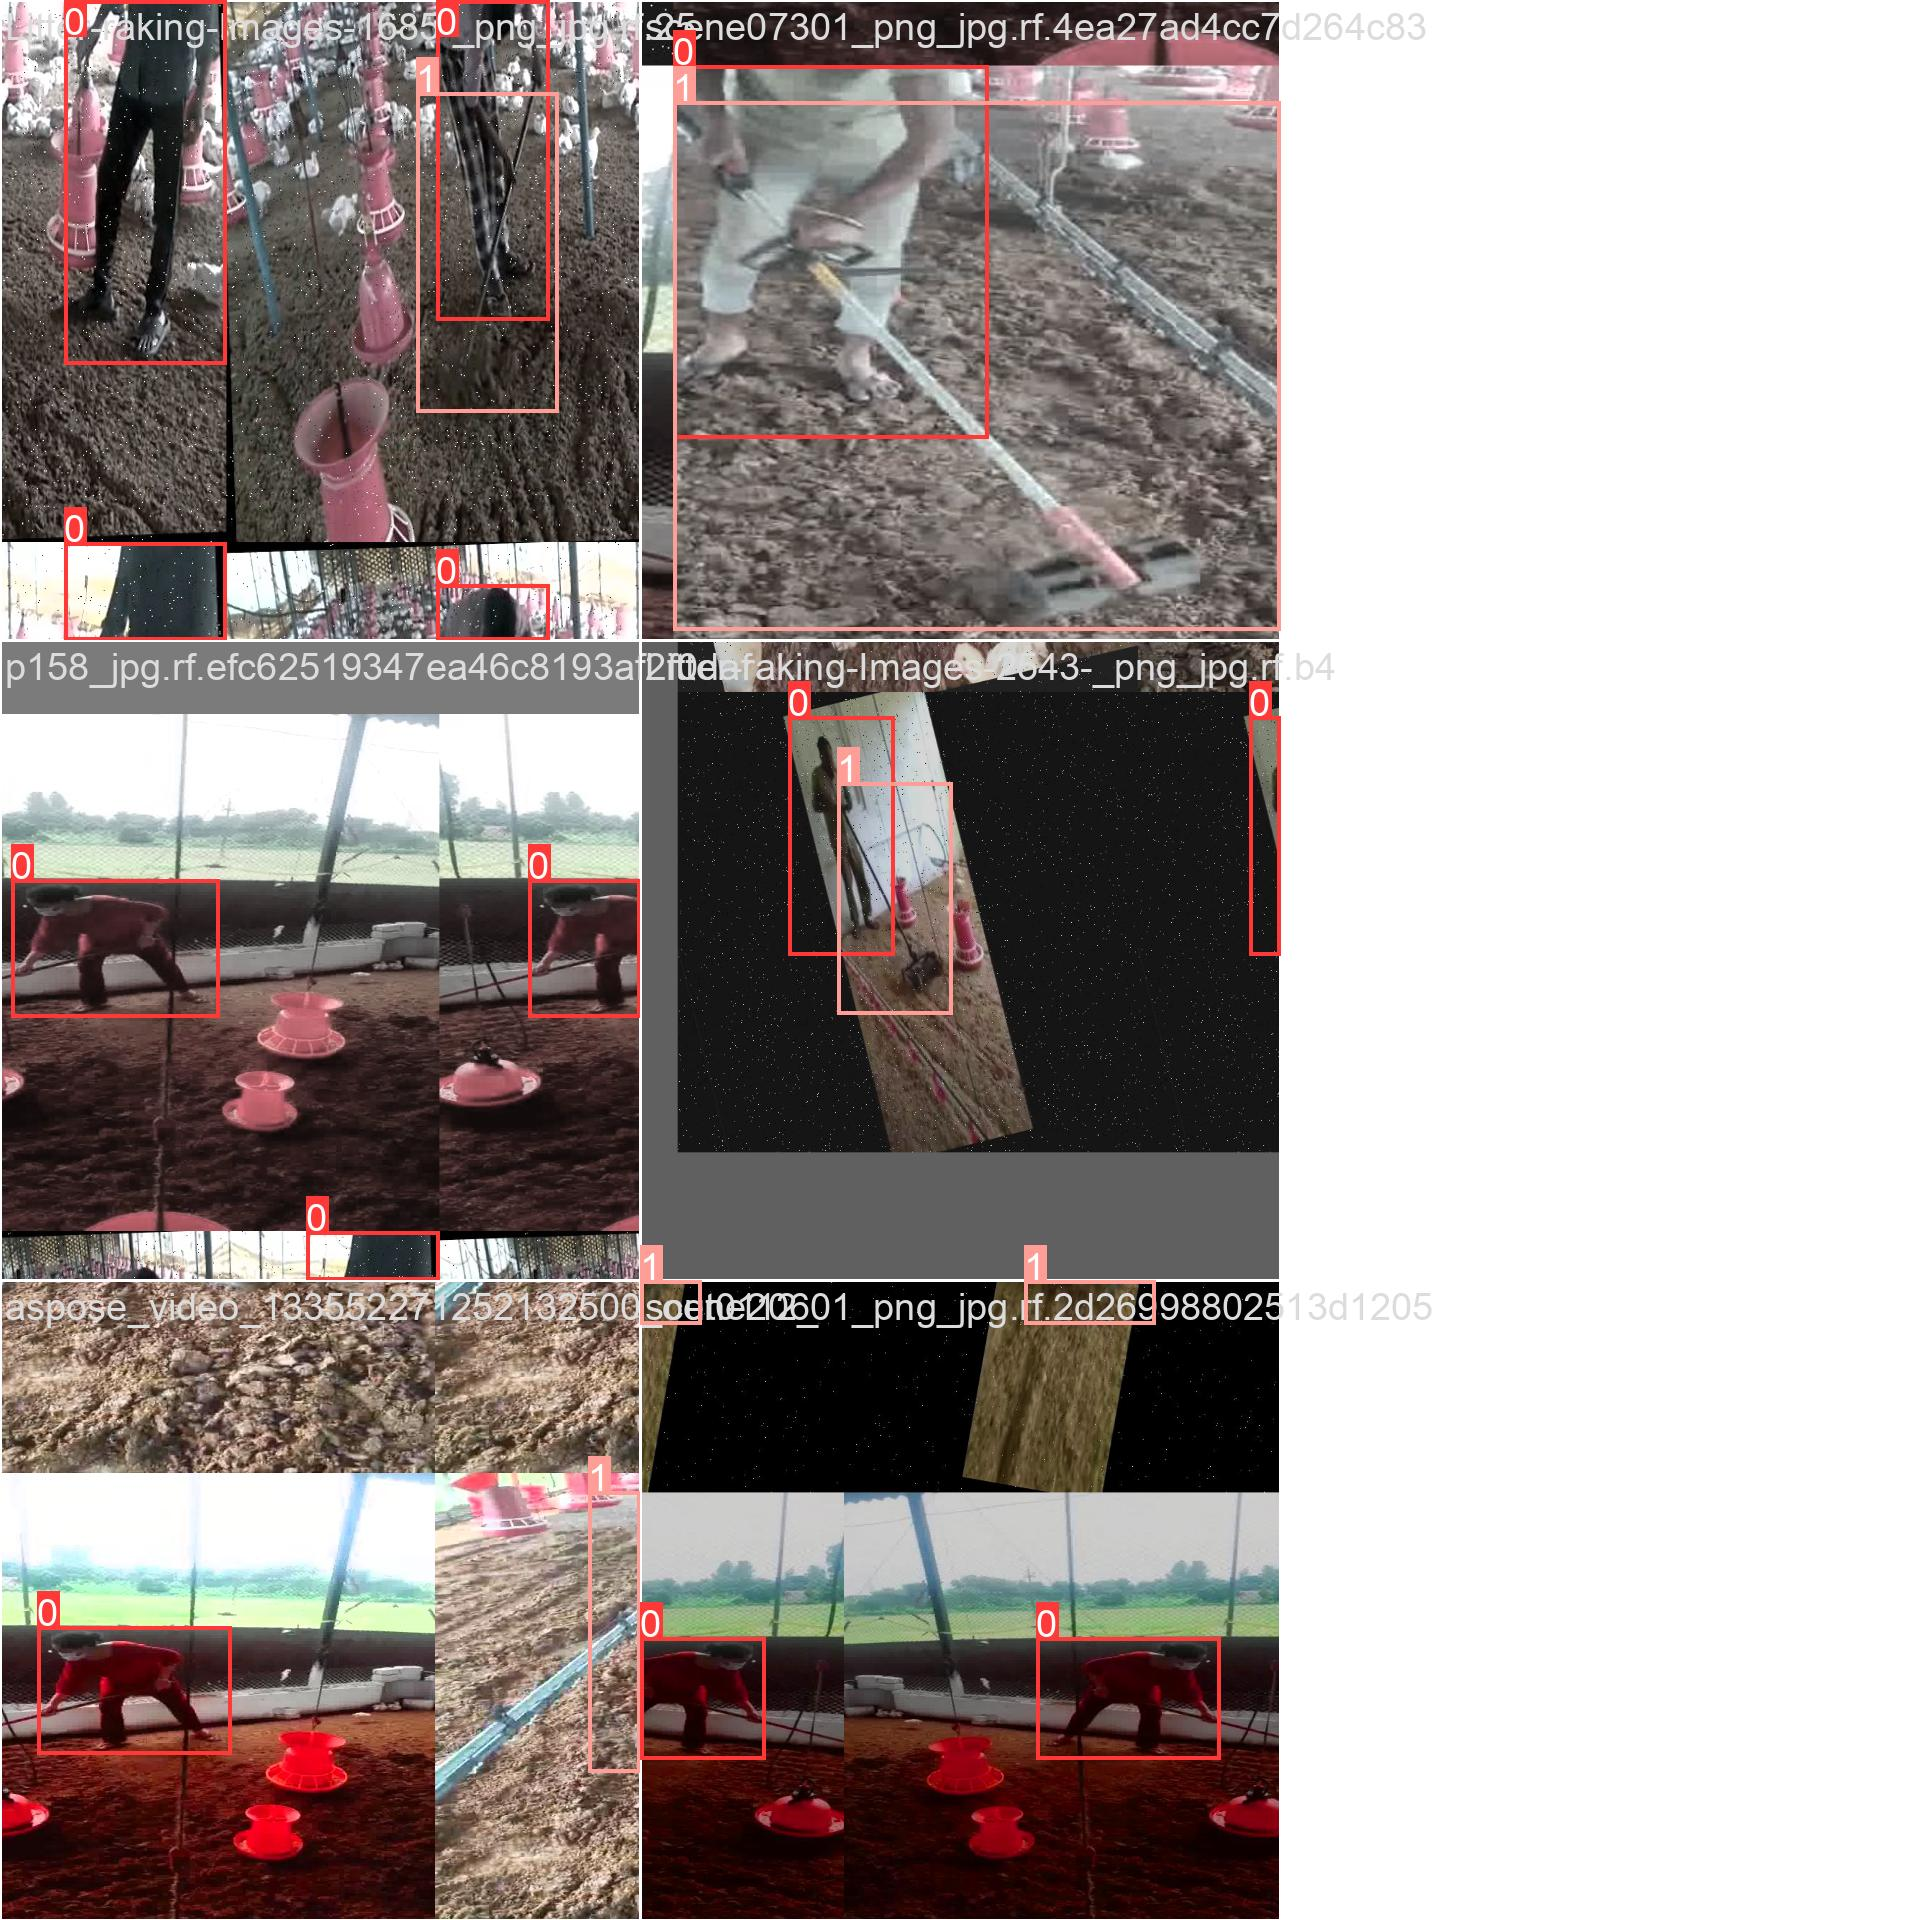

In [ ]:
# Define the path to the train image file
train_path = '/content/drive/MyDrive/Litte-Racking-Project-files Drive/train2/train_batch1.jpg'

# Display the train image
Image(filename=train_path)

# Mount Google Drive


In [ ]:
import os
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# # Define the output directory path in Google Drive
# output_dir = '/content/drive/MyDrive/YOLOv8_Training_Results'

# # Create the output directory if it doesn't exist
# if not os.path.exists(output_dir):
#     os.makedirs(output_dir)

# # Print the output directory path for verification
# print('Output Directory:', output_dir)


Output Directory: /content/drive/MyDrive/YOLOv8_Training_Results


# Copy the training results to Google Drive

In [ ]:
%cp -r /content/smart-poultry-farm-litter-raking-3/runs/detect /content/drive/MyDrive/Litte-Racking-Project-files\ Drive


# Perform validation

In [ ]:
# Validation
!yolo detect val  model=/content/smart-poultry-farm-litter-raking-3/runs/detect/train2/weights/best.pt  data=/content/smart-poultry-farm-litter-raking-3/data.yaml imgsz=640 save_json=True save_hybrid=True

Ultralytics YOLOv8.1.40 🚀 Python-3.10.12 torch-2.2.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
YOLOv8m summary (fused): 218 layers, 25840918 parameters, 0 gradients, 78.7 GFLOPs
val: Scanning /content/smart-poultry-farm-litter-raking-3/valid/labels.cache... 1181 images, 0 backgrounds, 0 corrupt: 100% 1181/1181 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 74/74 [00:35<00:00,  2.11it/s]
                   all       1181       2223          1      0.999      0.995      0.995
                 human       1181       1089          1      0.998      0.995      0.995
               machine       1181       1134          1          1      0.995      0.995
Speed: 1.0ms preprocess, 20.1ms inference, 0.0ms loss, 2.5ms postprocess per image
Saving runs/detect/val/predictions.json...
Results saved to runs/detect/val
💡 Learn more at https://docs.ultralytics.com/modes/val


# Visualize valid set Images

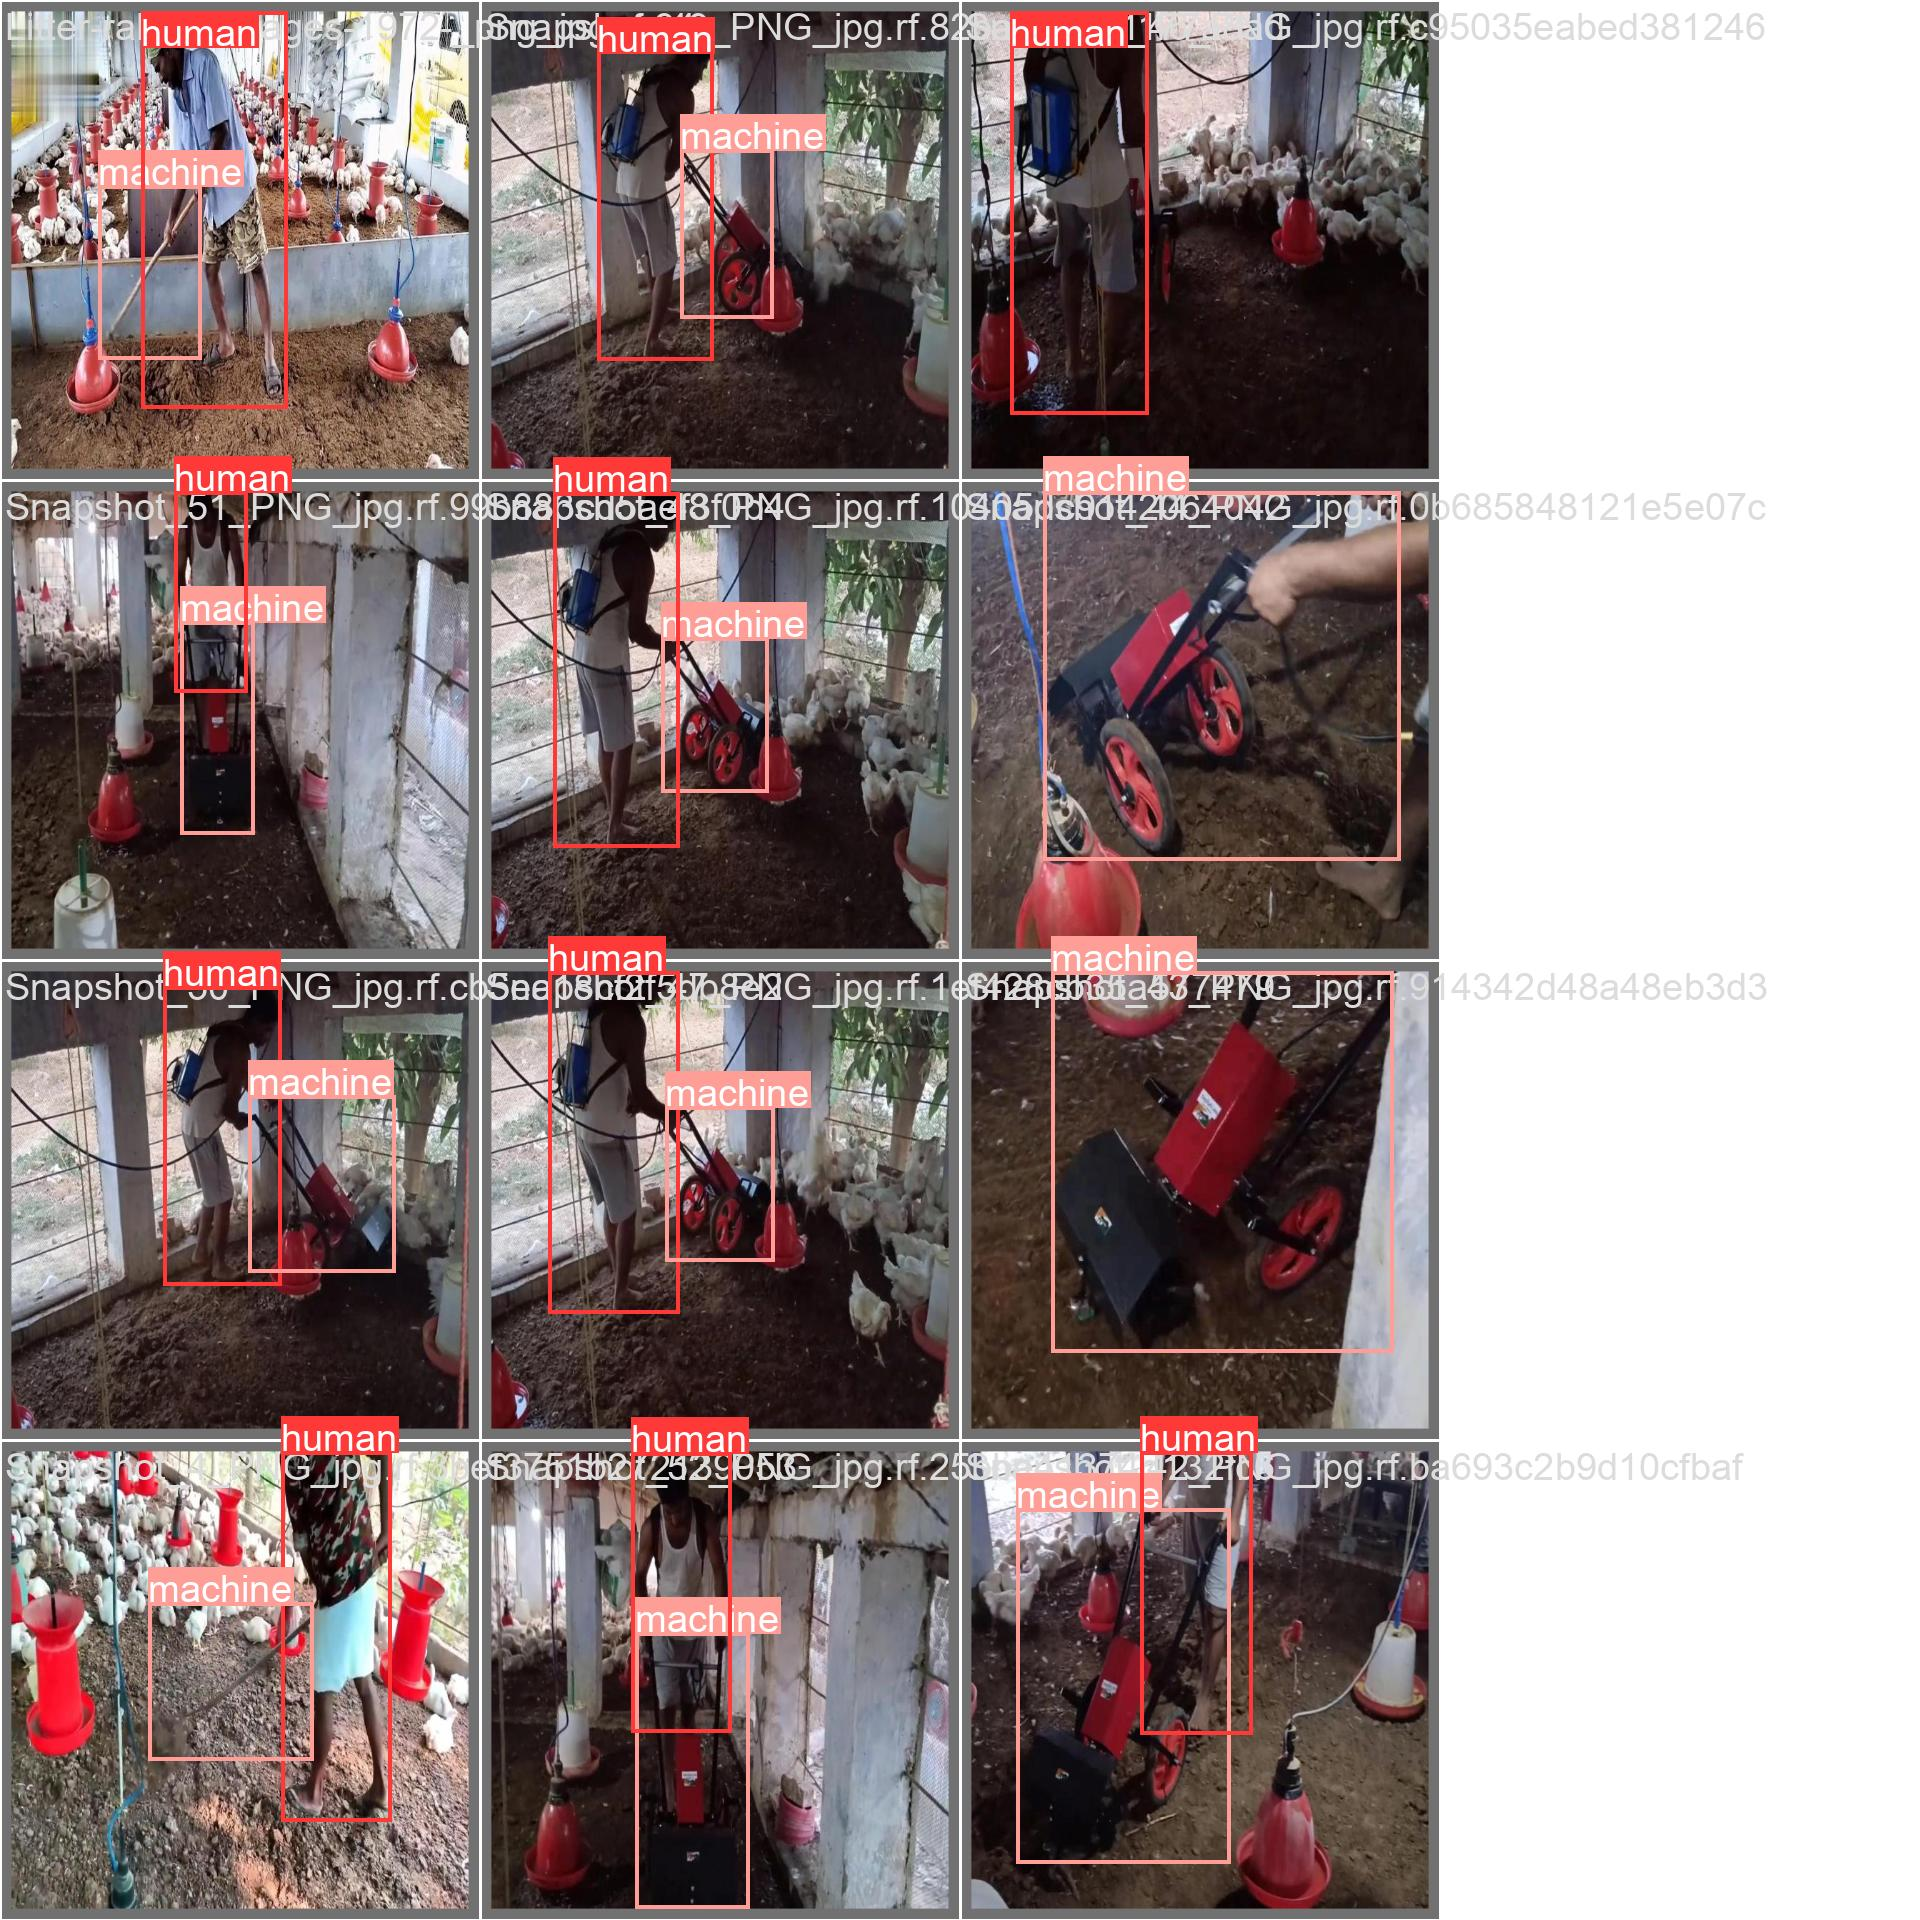

In [ ]:
# Define the path to the train image file
valid_path = '/content/drive/MyDrive/Litte-Racking-Project-files Drive/train2/val_batch0_labels.jpg'

# Display the train image
Image(filename=valid_path)

# Visualize predict on valid dataset

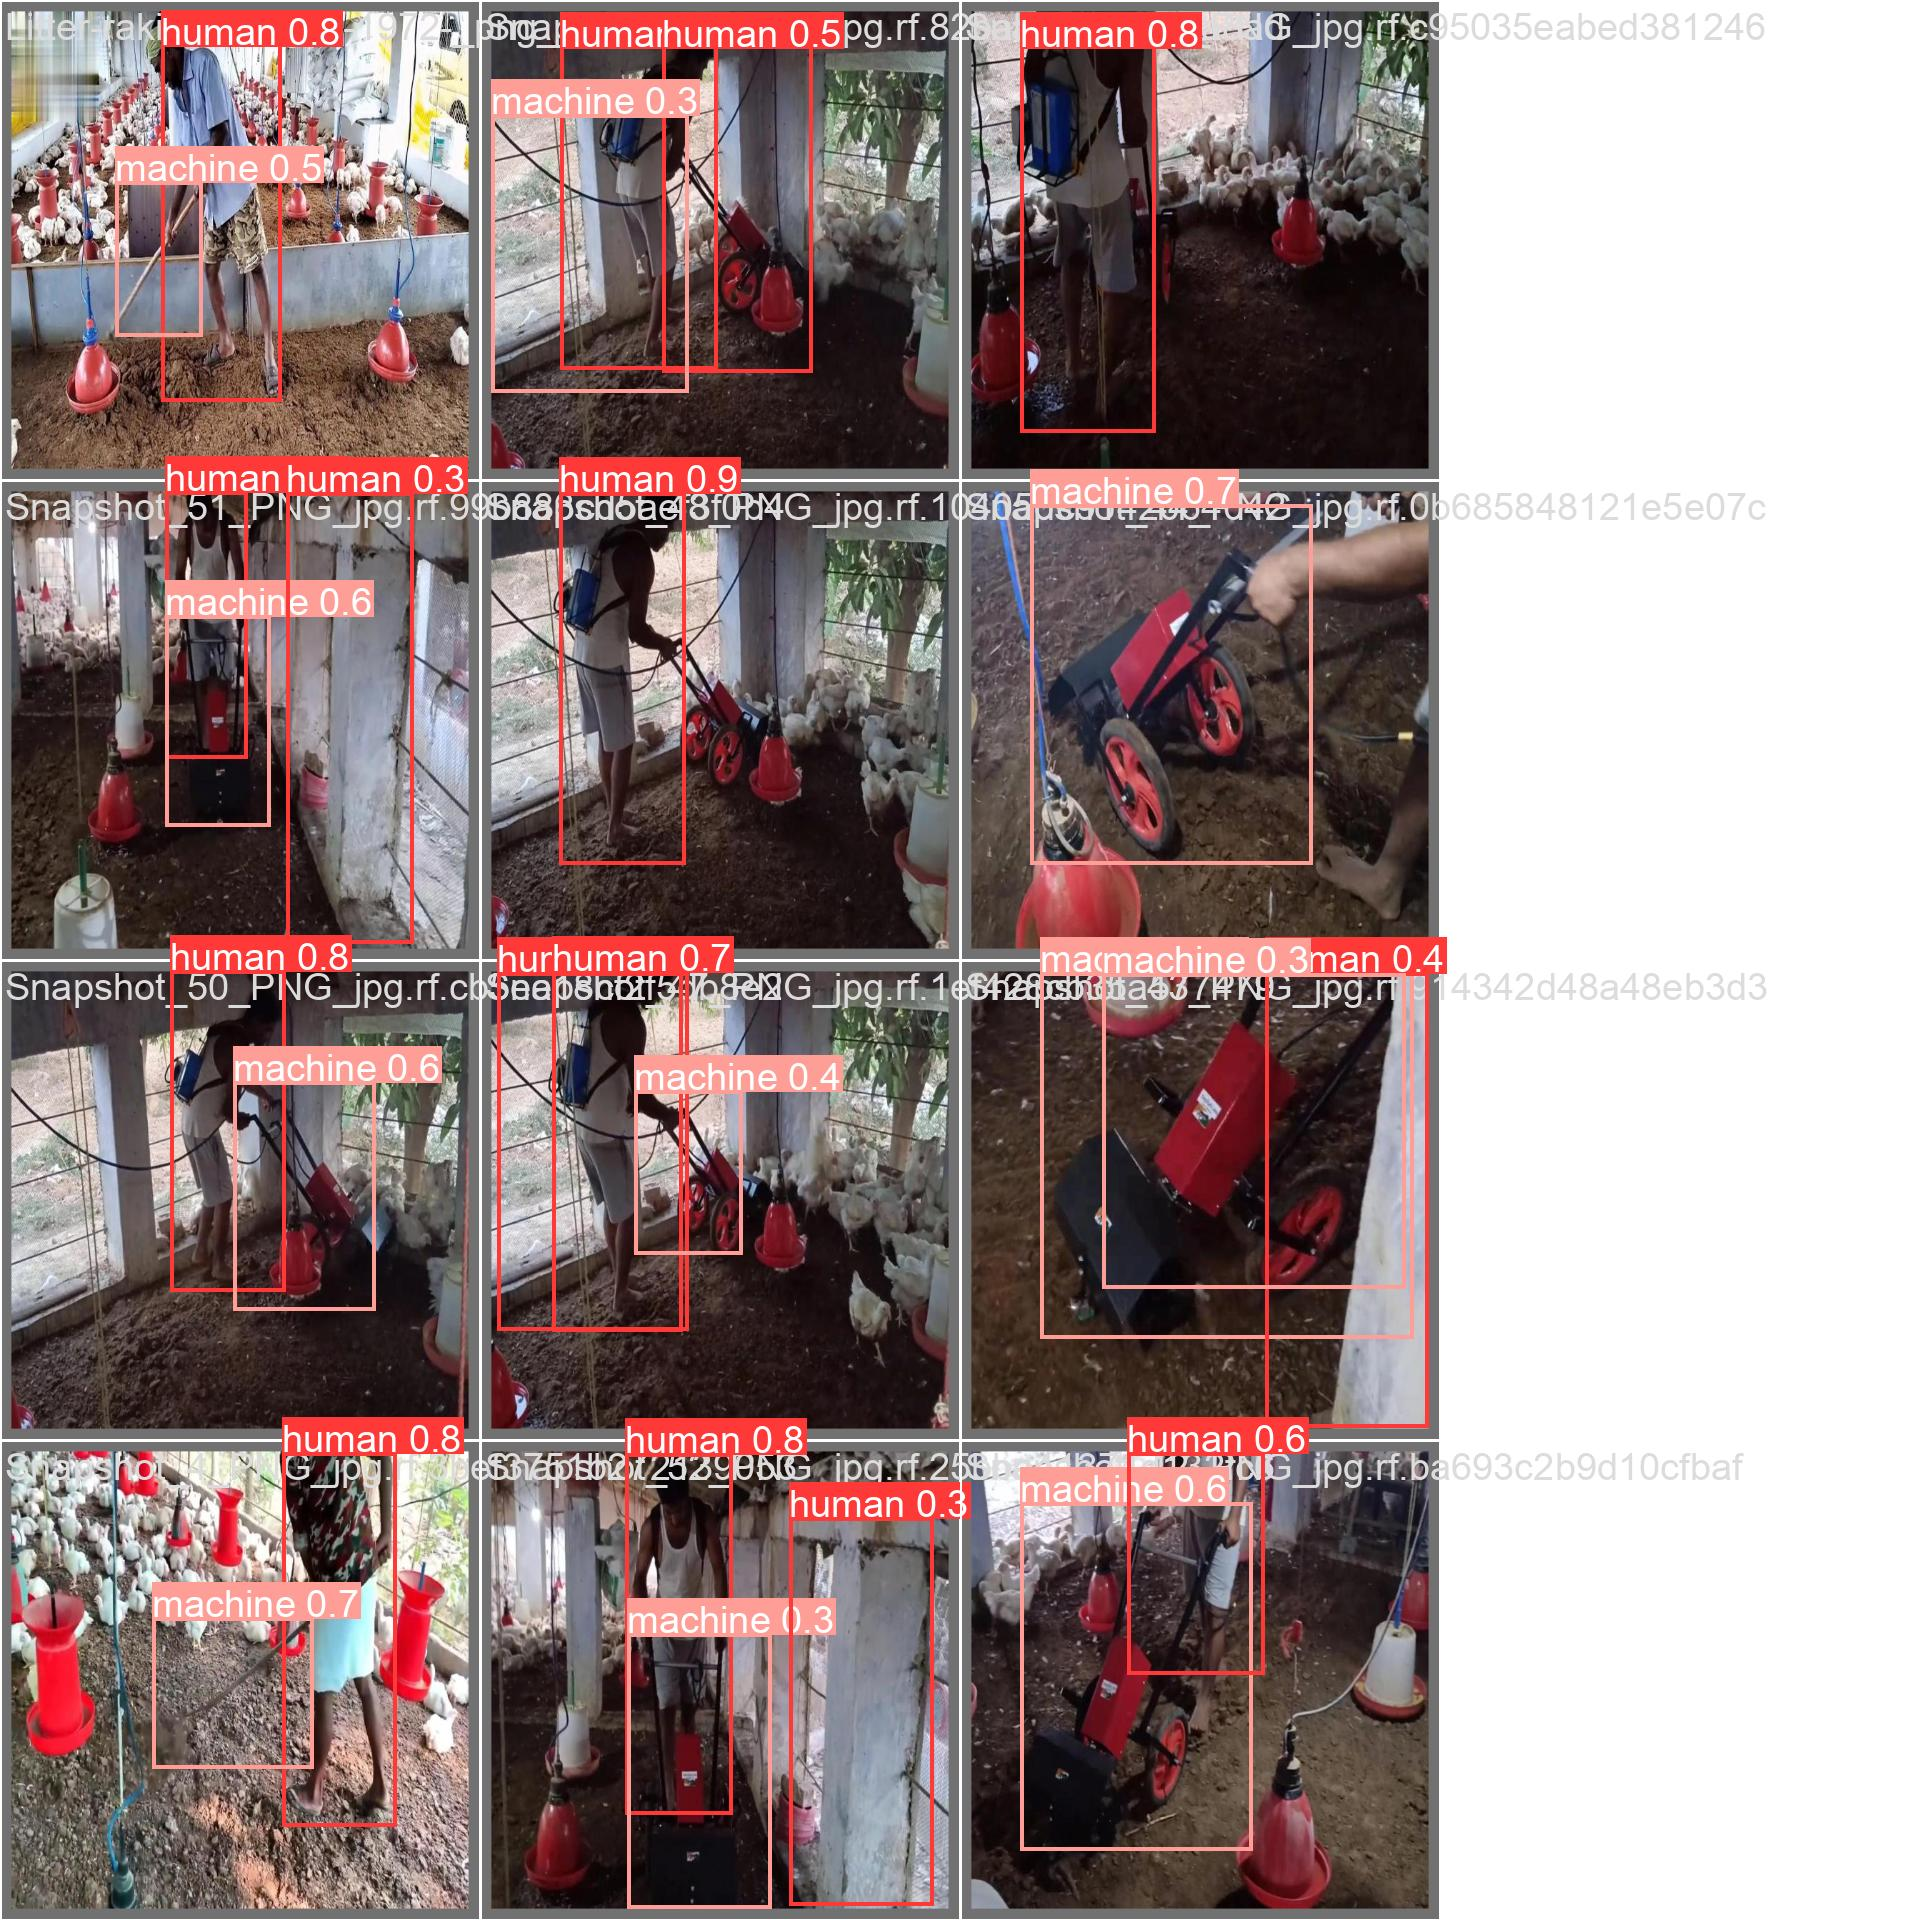

In [ ]:
# Define the path to the train image file
valid_path = '/content/drive/MyDrive/Litte-Racking-Project-files Drive/train2/val_batch0_pred.jpg'

# Display the train image
Image(filename=valid_path)

#Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Perform Test

In [ ]:
# Test
!yolo detect predict  model=/content/drive/MyDrive/Litte-Racking-Project-files Drive/train2/weights/best.pt conf=0.25 source=/content/smart-poultry-farm-litter-raking-3/test/images show=True save=True save_txt=True save_conf=True show_labels=True show_conf=True show_boxes=True

# Visualize F1_curve

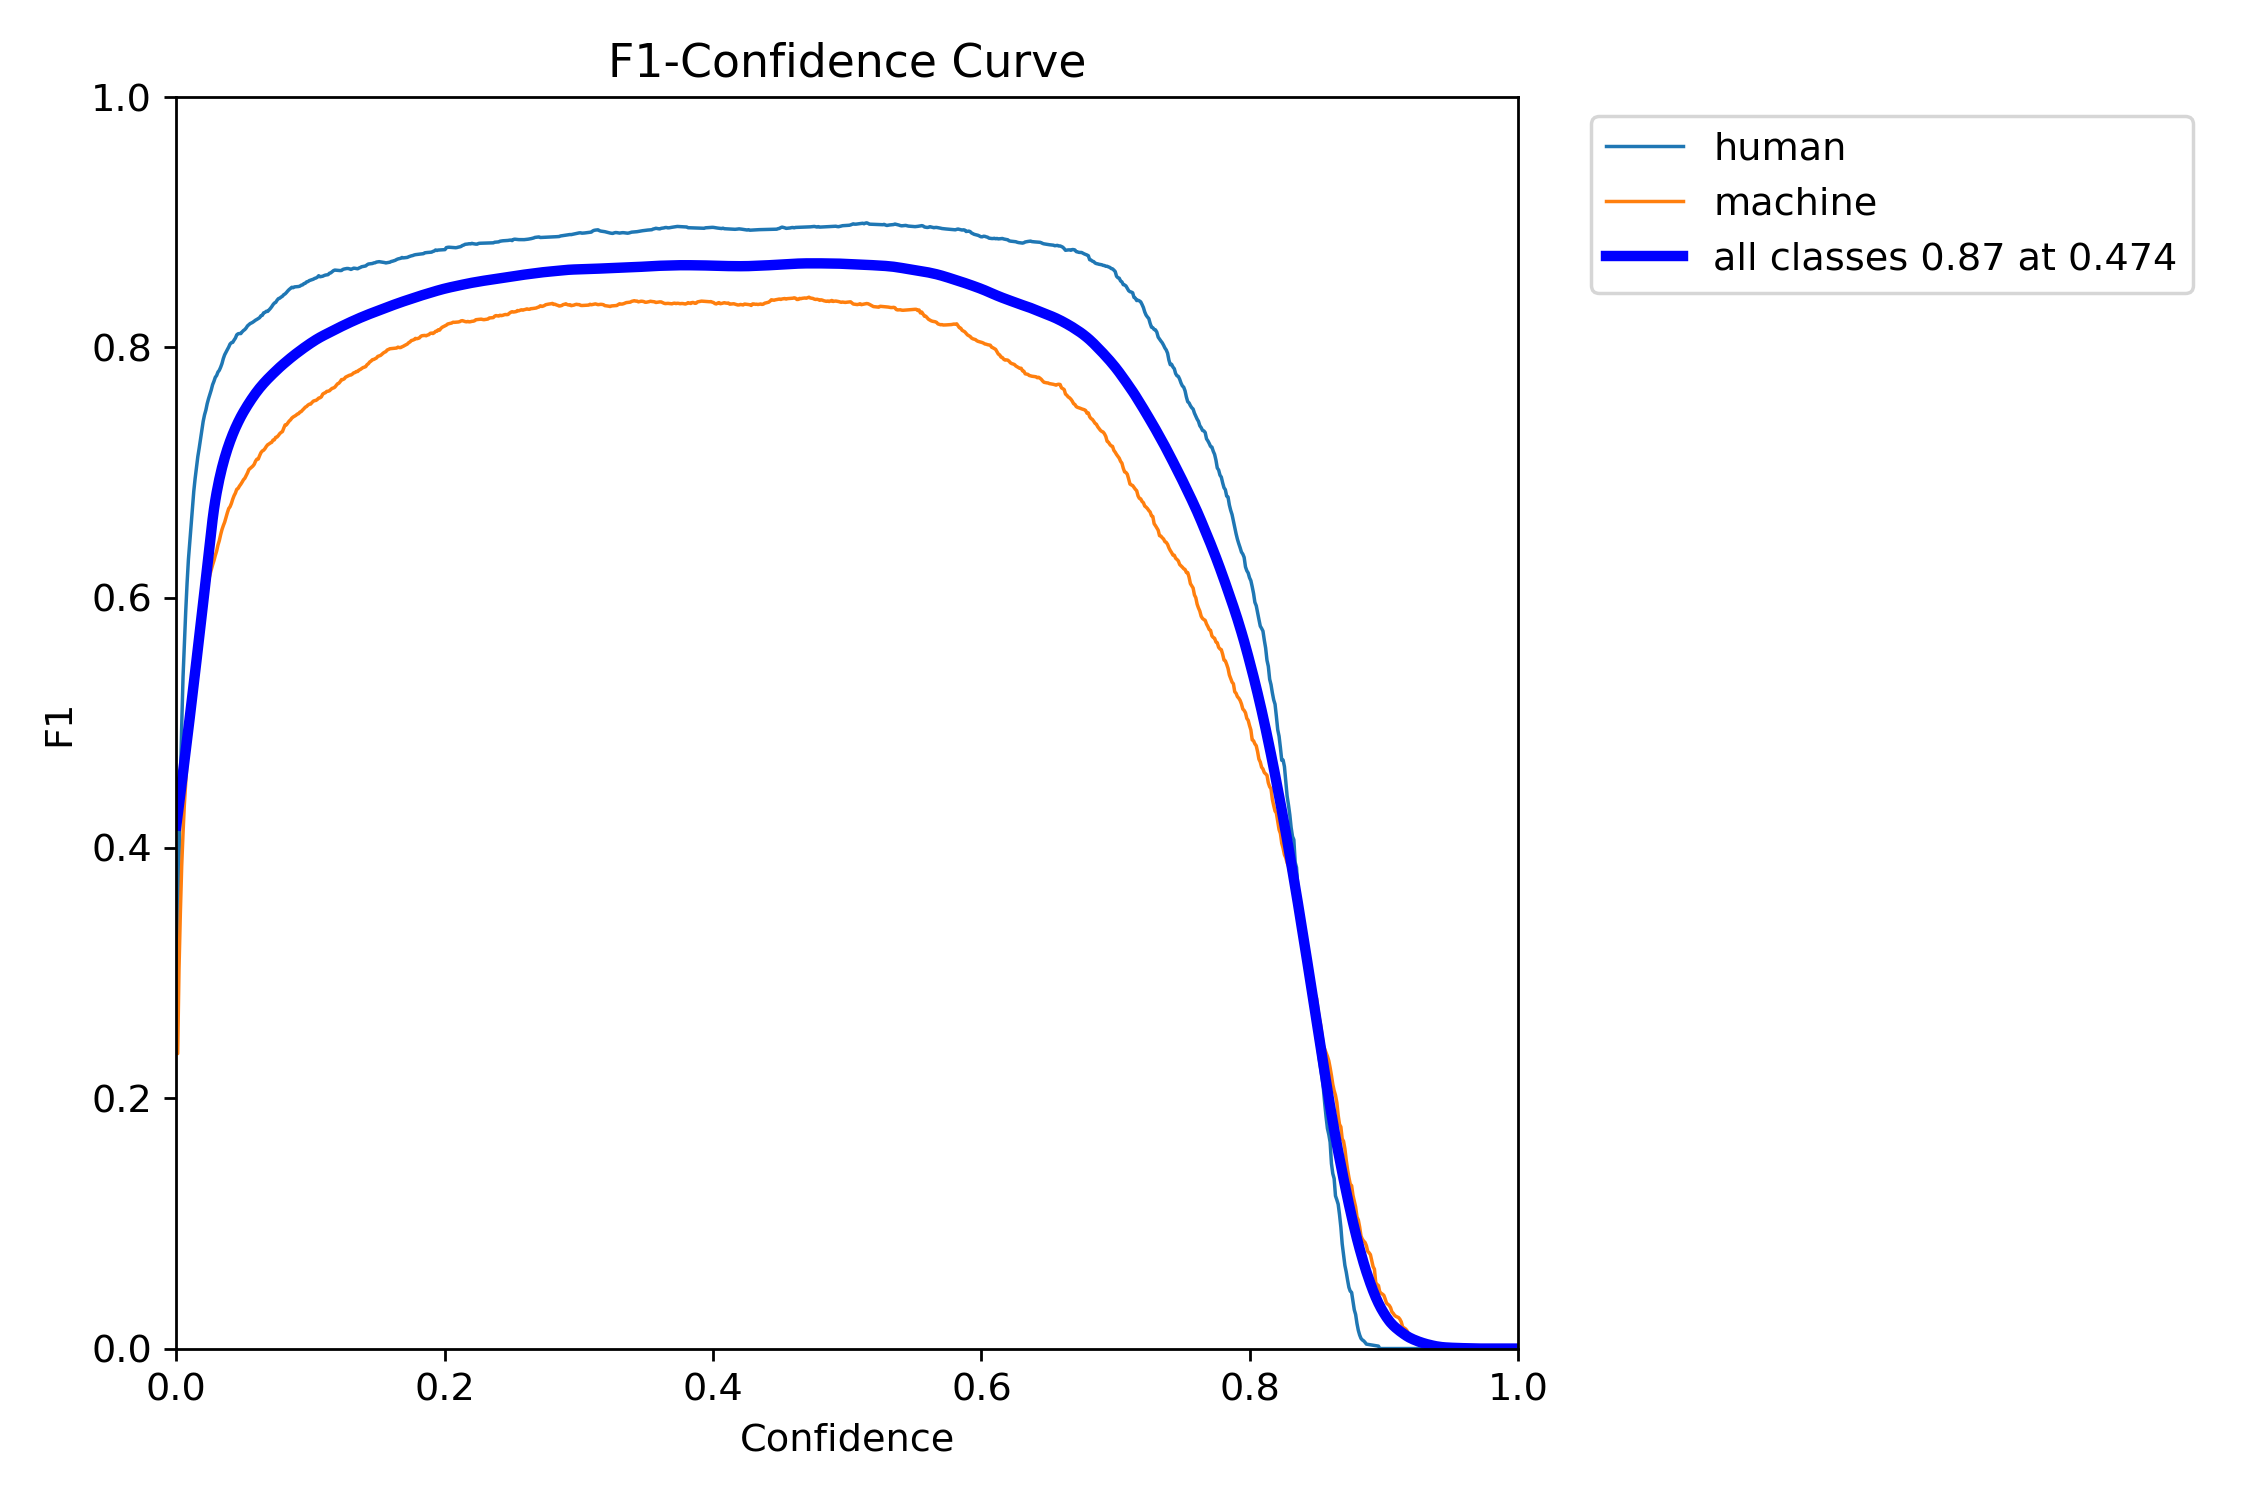

In [ ]:
# Define the path to the F1_curve image file
f1_curve_path = '/content/drive/MyDrive/Litte-Racking-Project-files Drive/train2/F1_curve.png'

# Display the F1_curve image
Image(filename=f1_curve_path, width=640)


# Visualize PR_curve

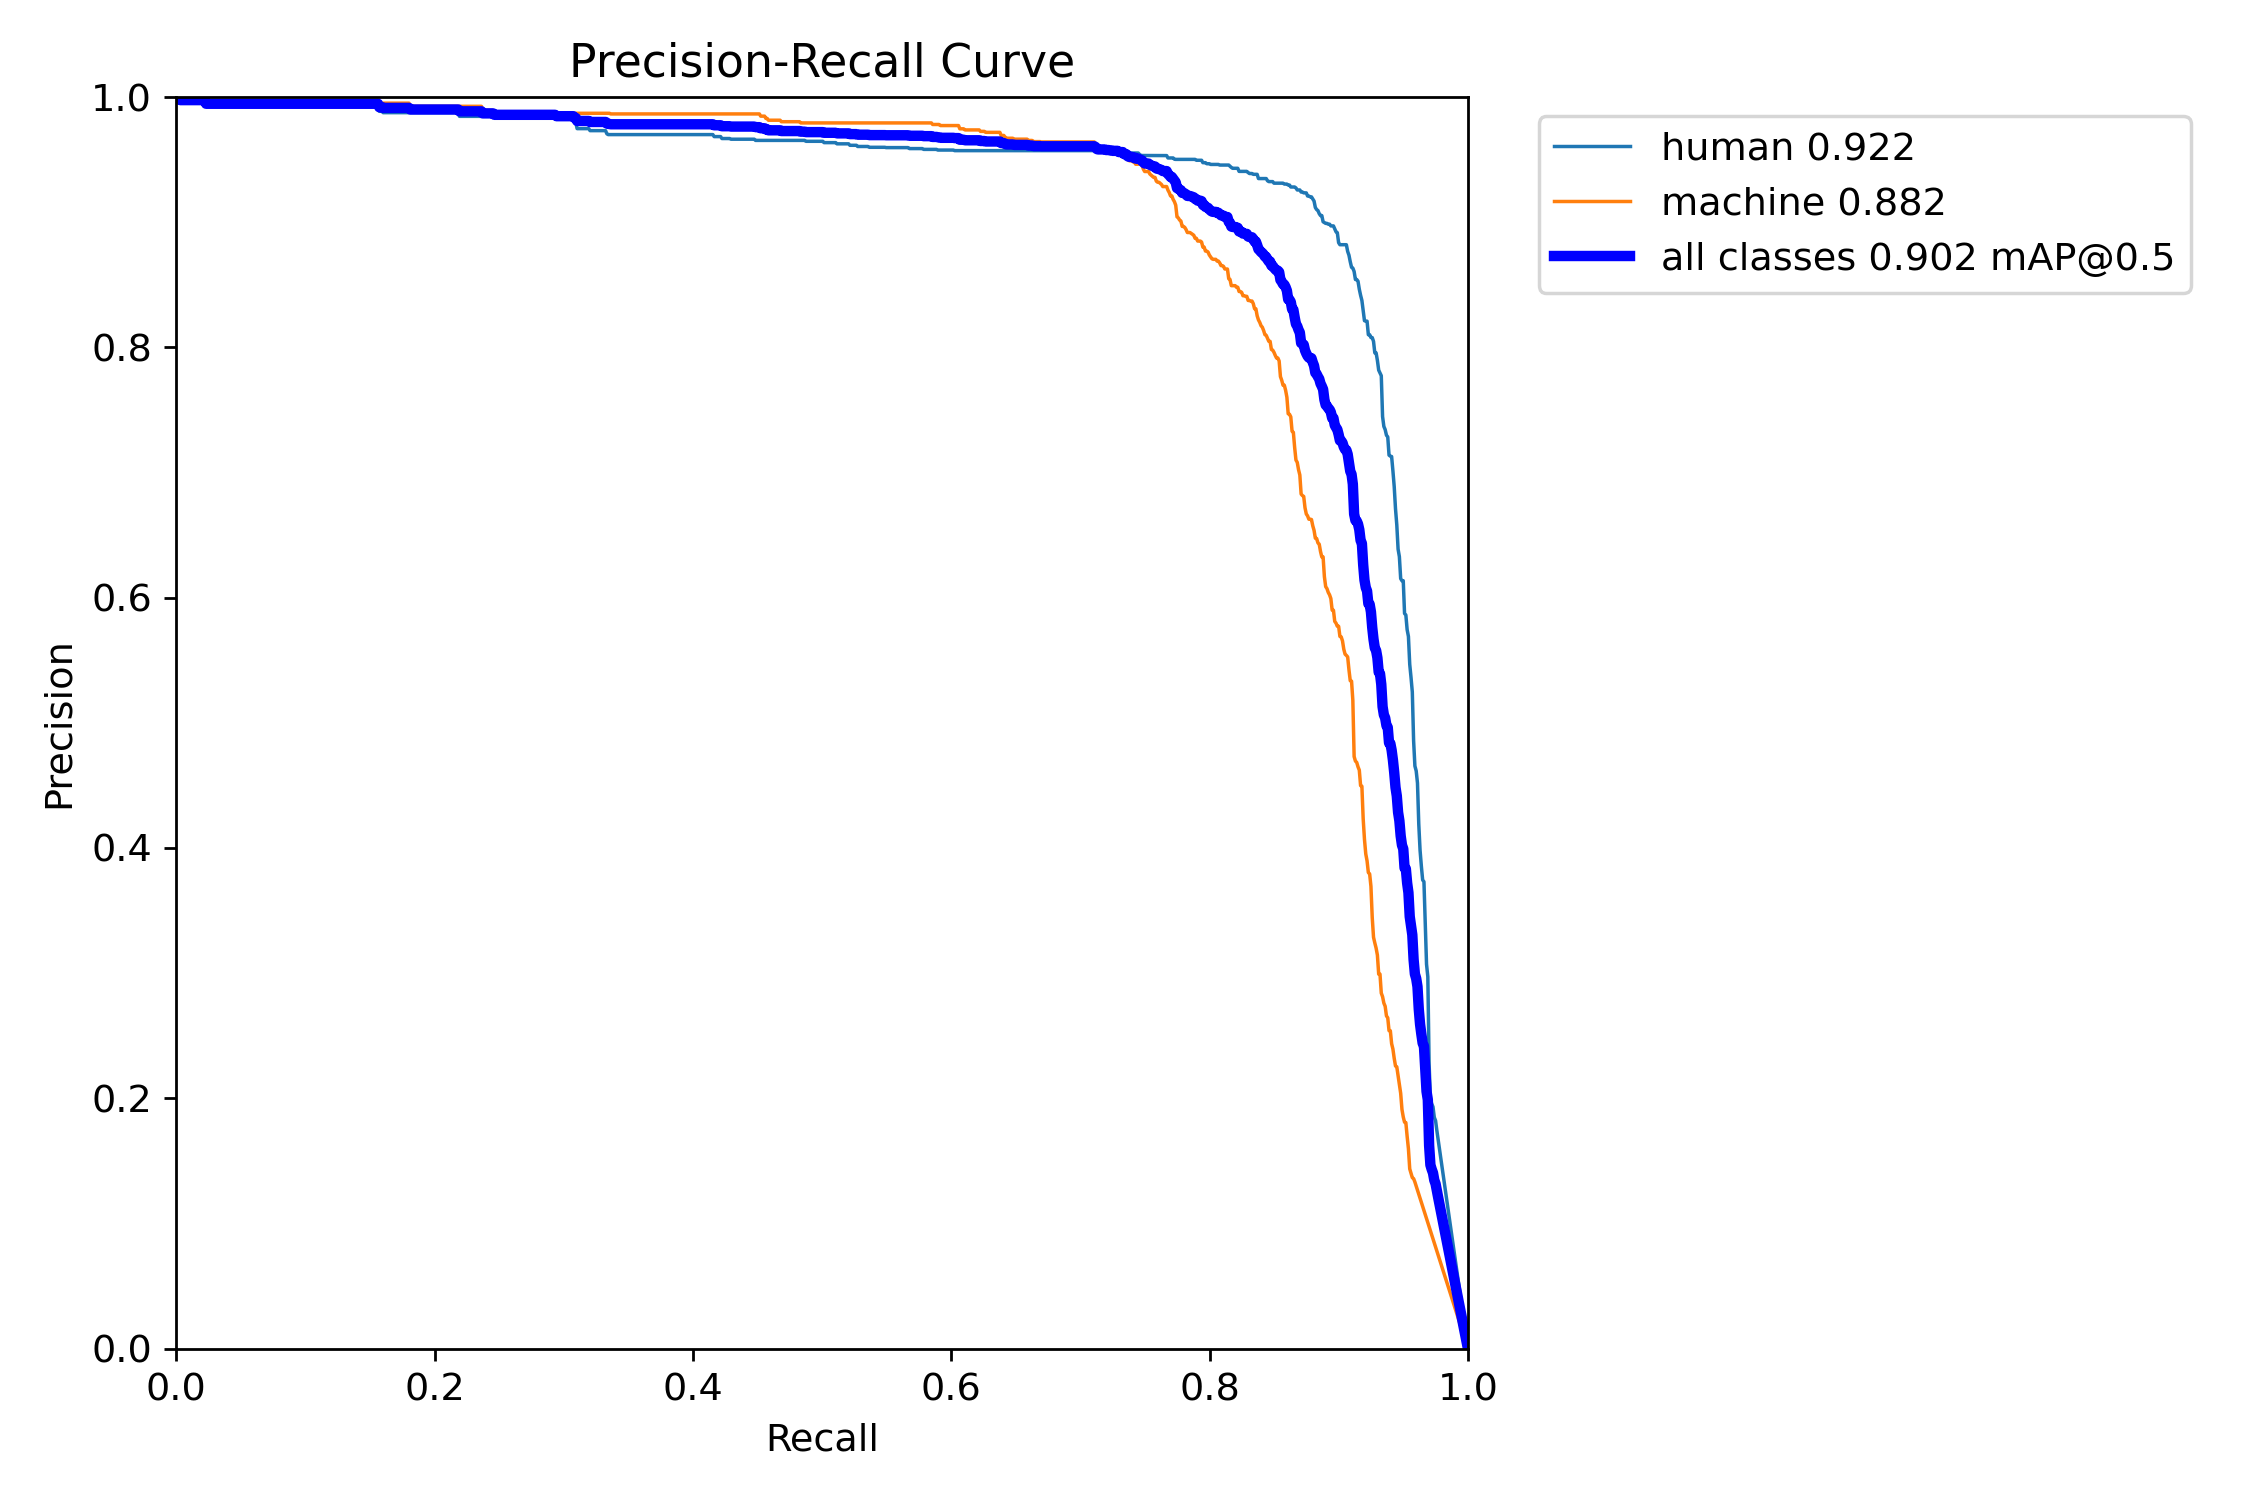

In [ ]:

pr_curve_path = '/content/drive/MyDrive/Litte-Racking-Project-files Drive/train2/PR_curve.png'


Image(filename=pr_curve_path, width=640)


# Visualize P_curve

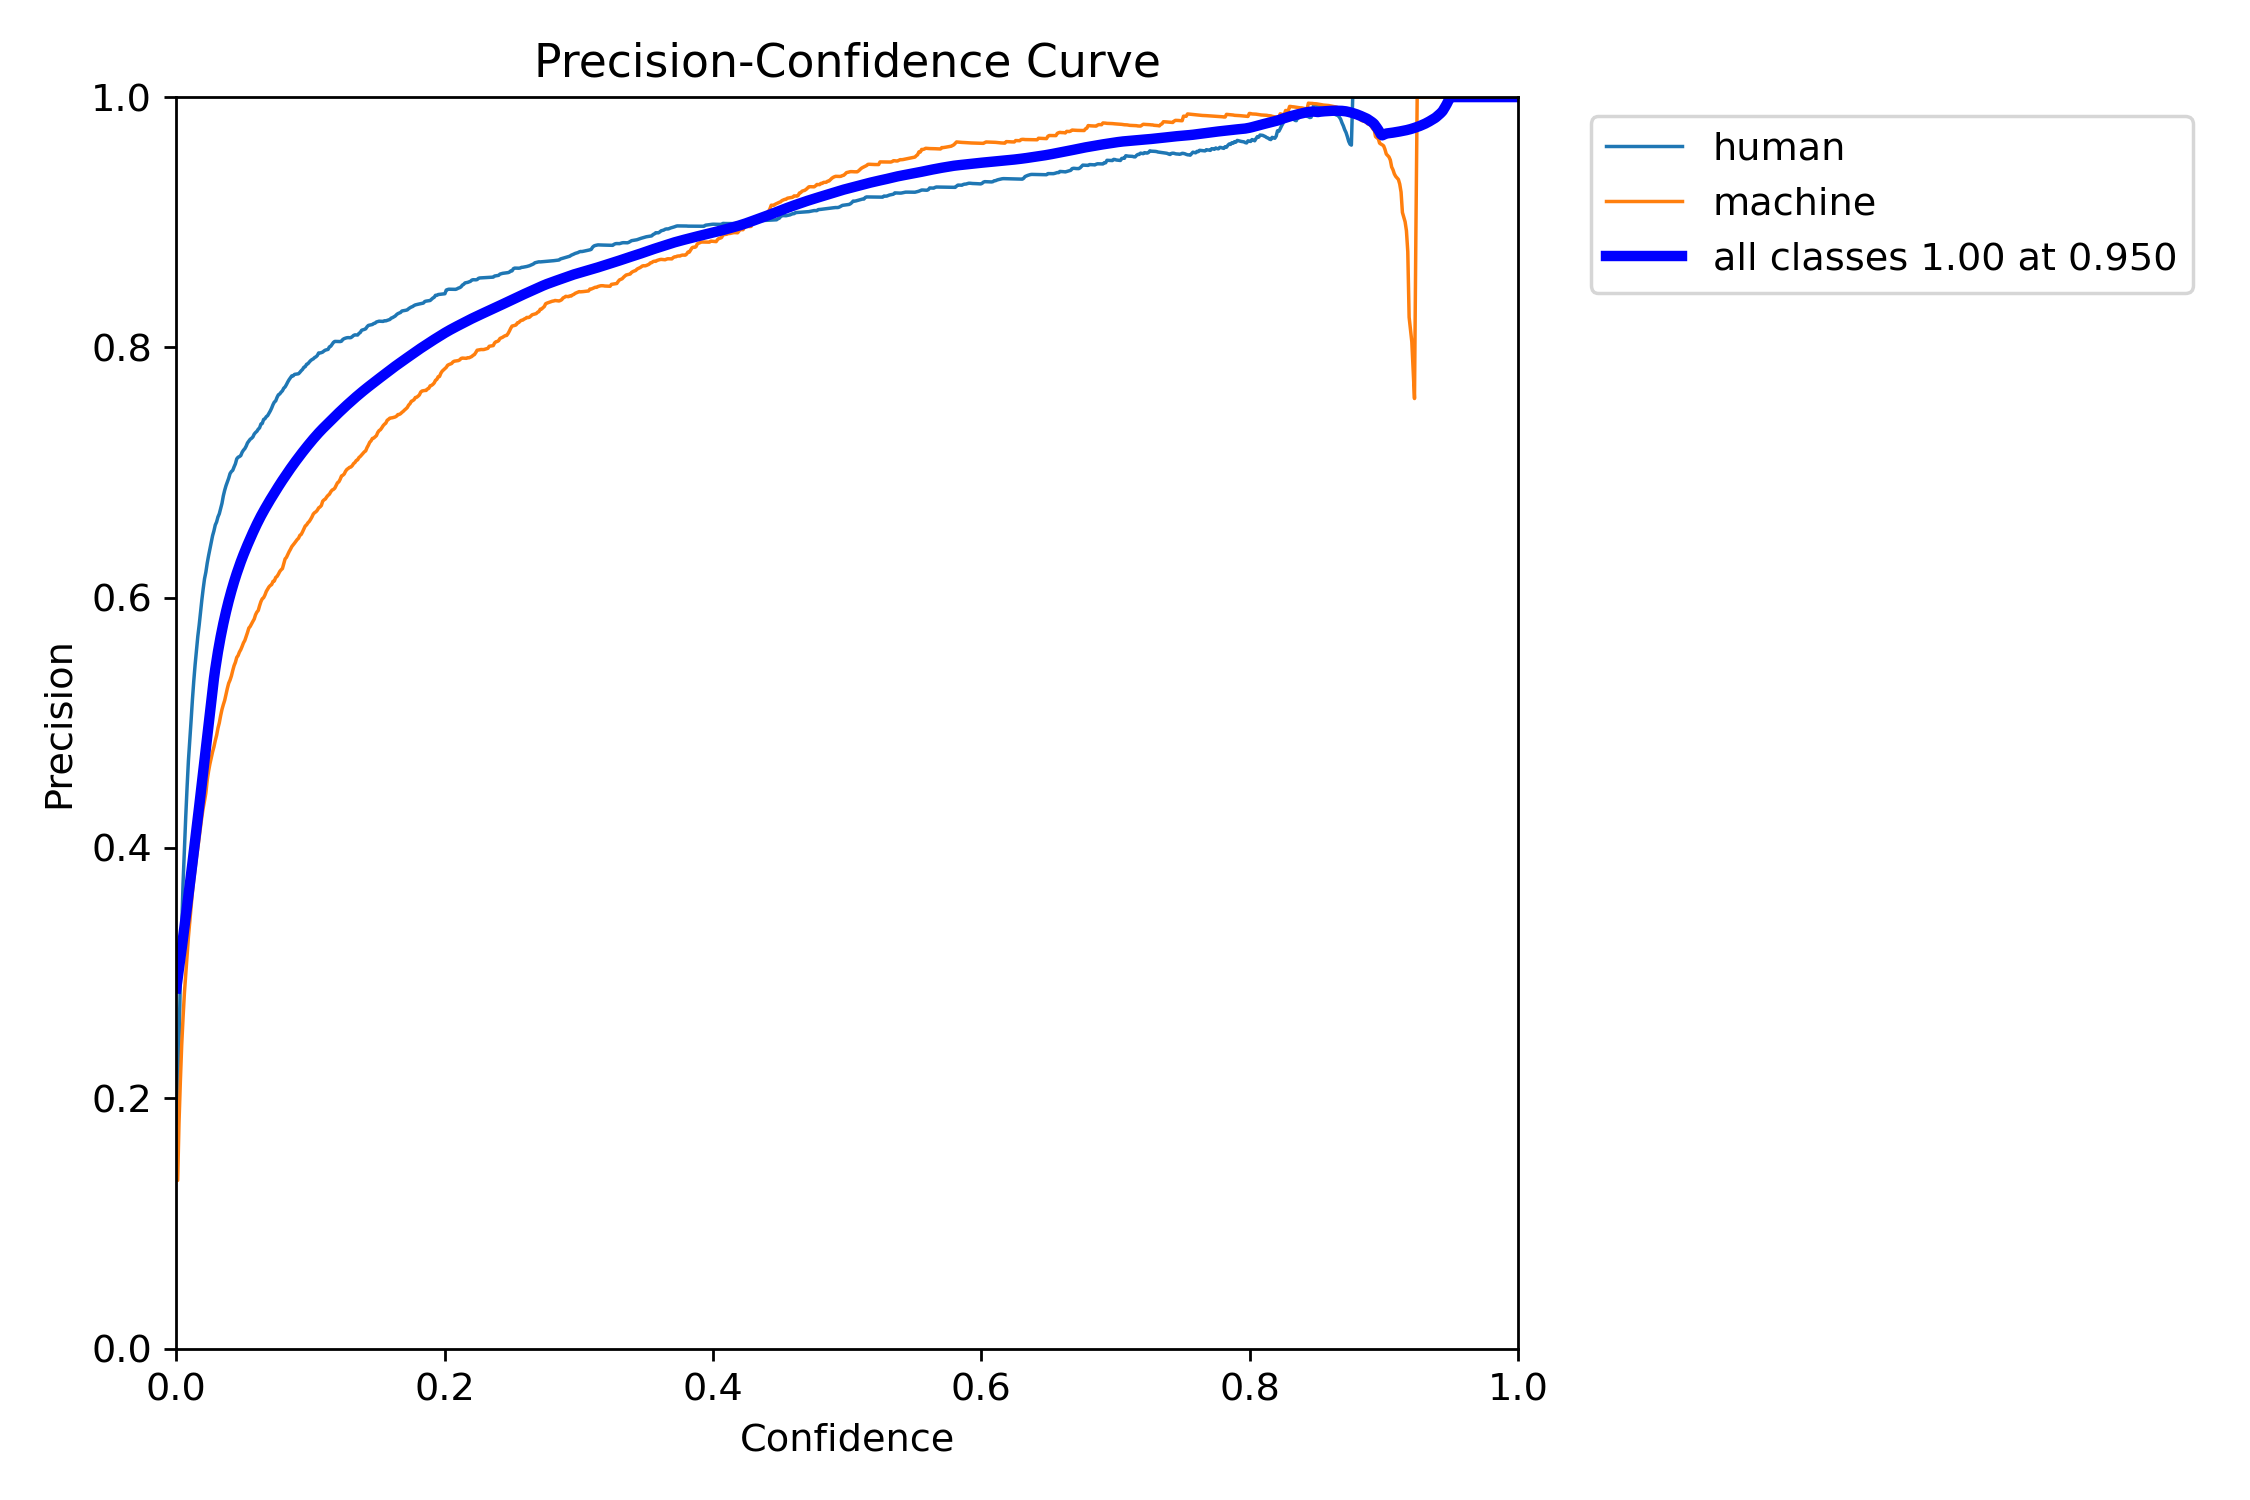

In [ ]:
# Define the path to the P_curve image file
p_curve_path = '/content/drive/MyDrive/Litte-Racking-Project-files Drive/train2/P_curve.png'

# Display the P_curve image
Image(filename=p_curve_path, width=640)


# Visualize R_curve

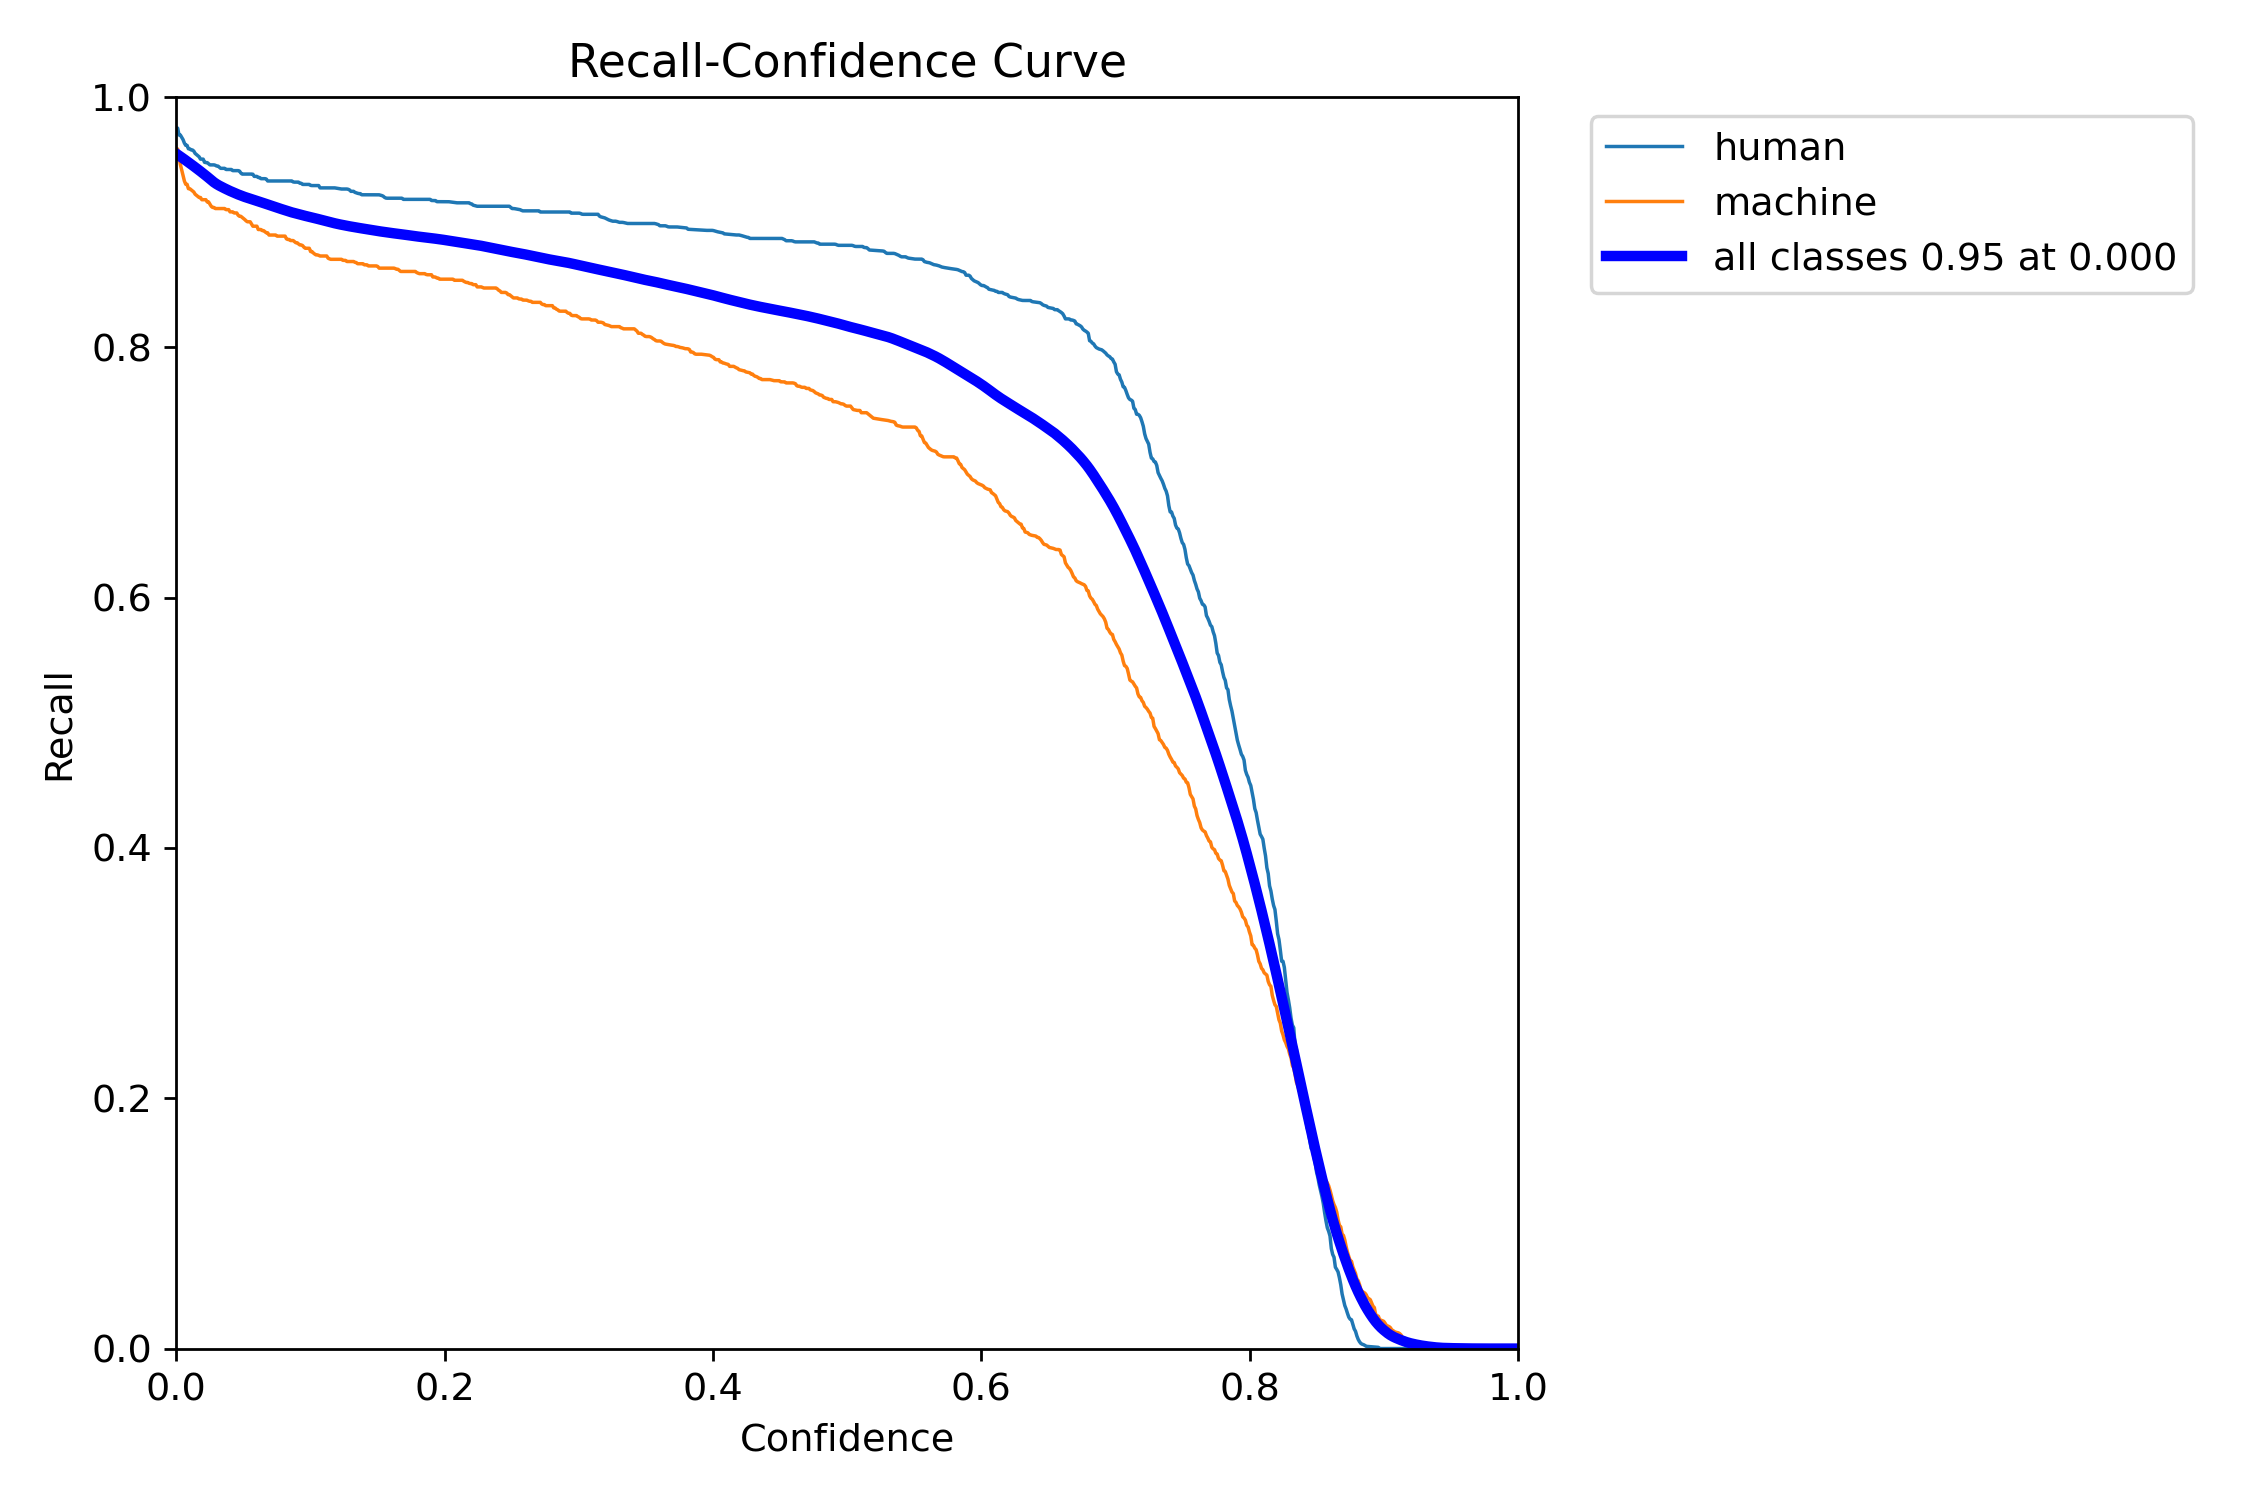

In [ ]:
# Define the path to the R_curve image file
r_curve_path = '/content/drive/MyDrive/Litte-Racking-Project-files Drive/train2/R_curve.png'

# Display the R_curve image
Image(filename=r_curve_path, width=640)


# Visualize the confusion matrix

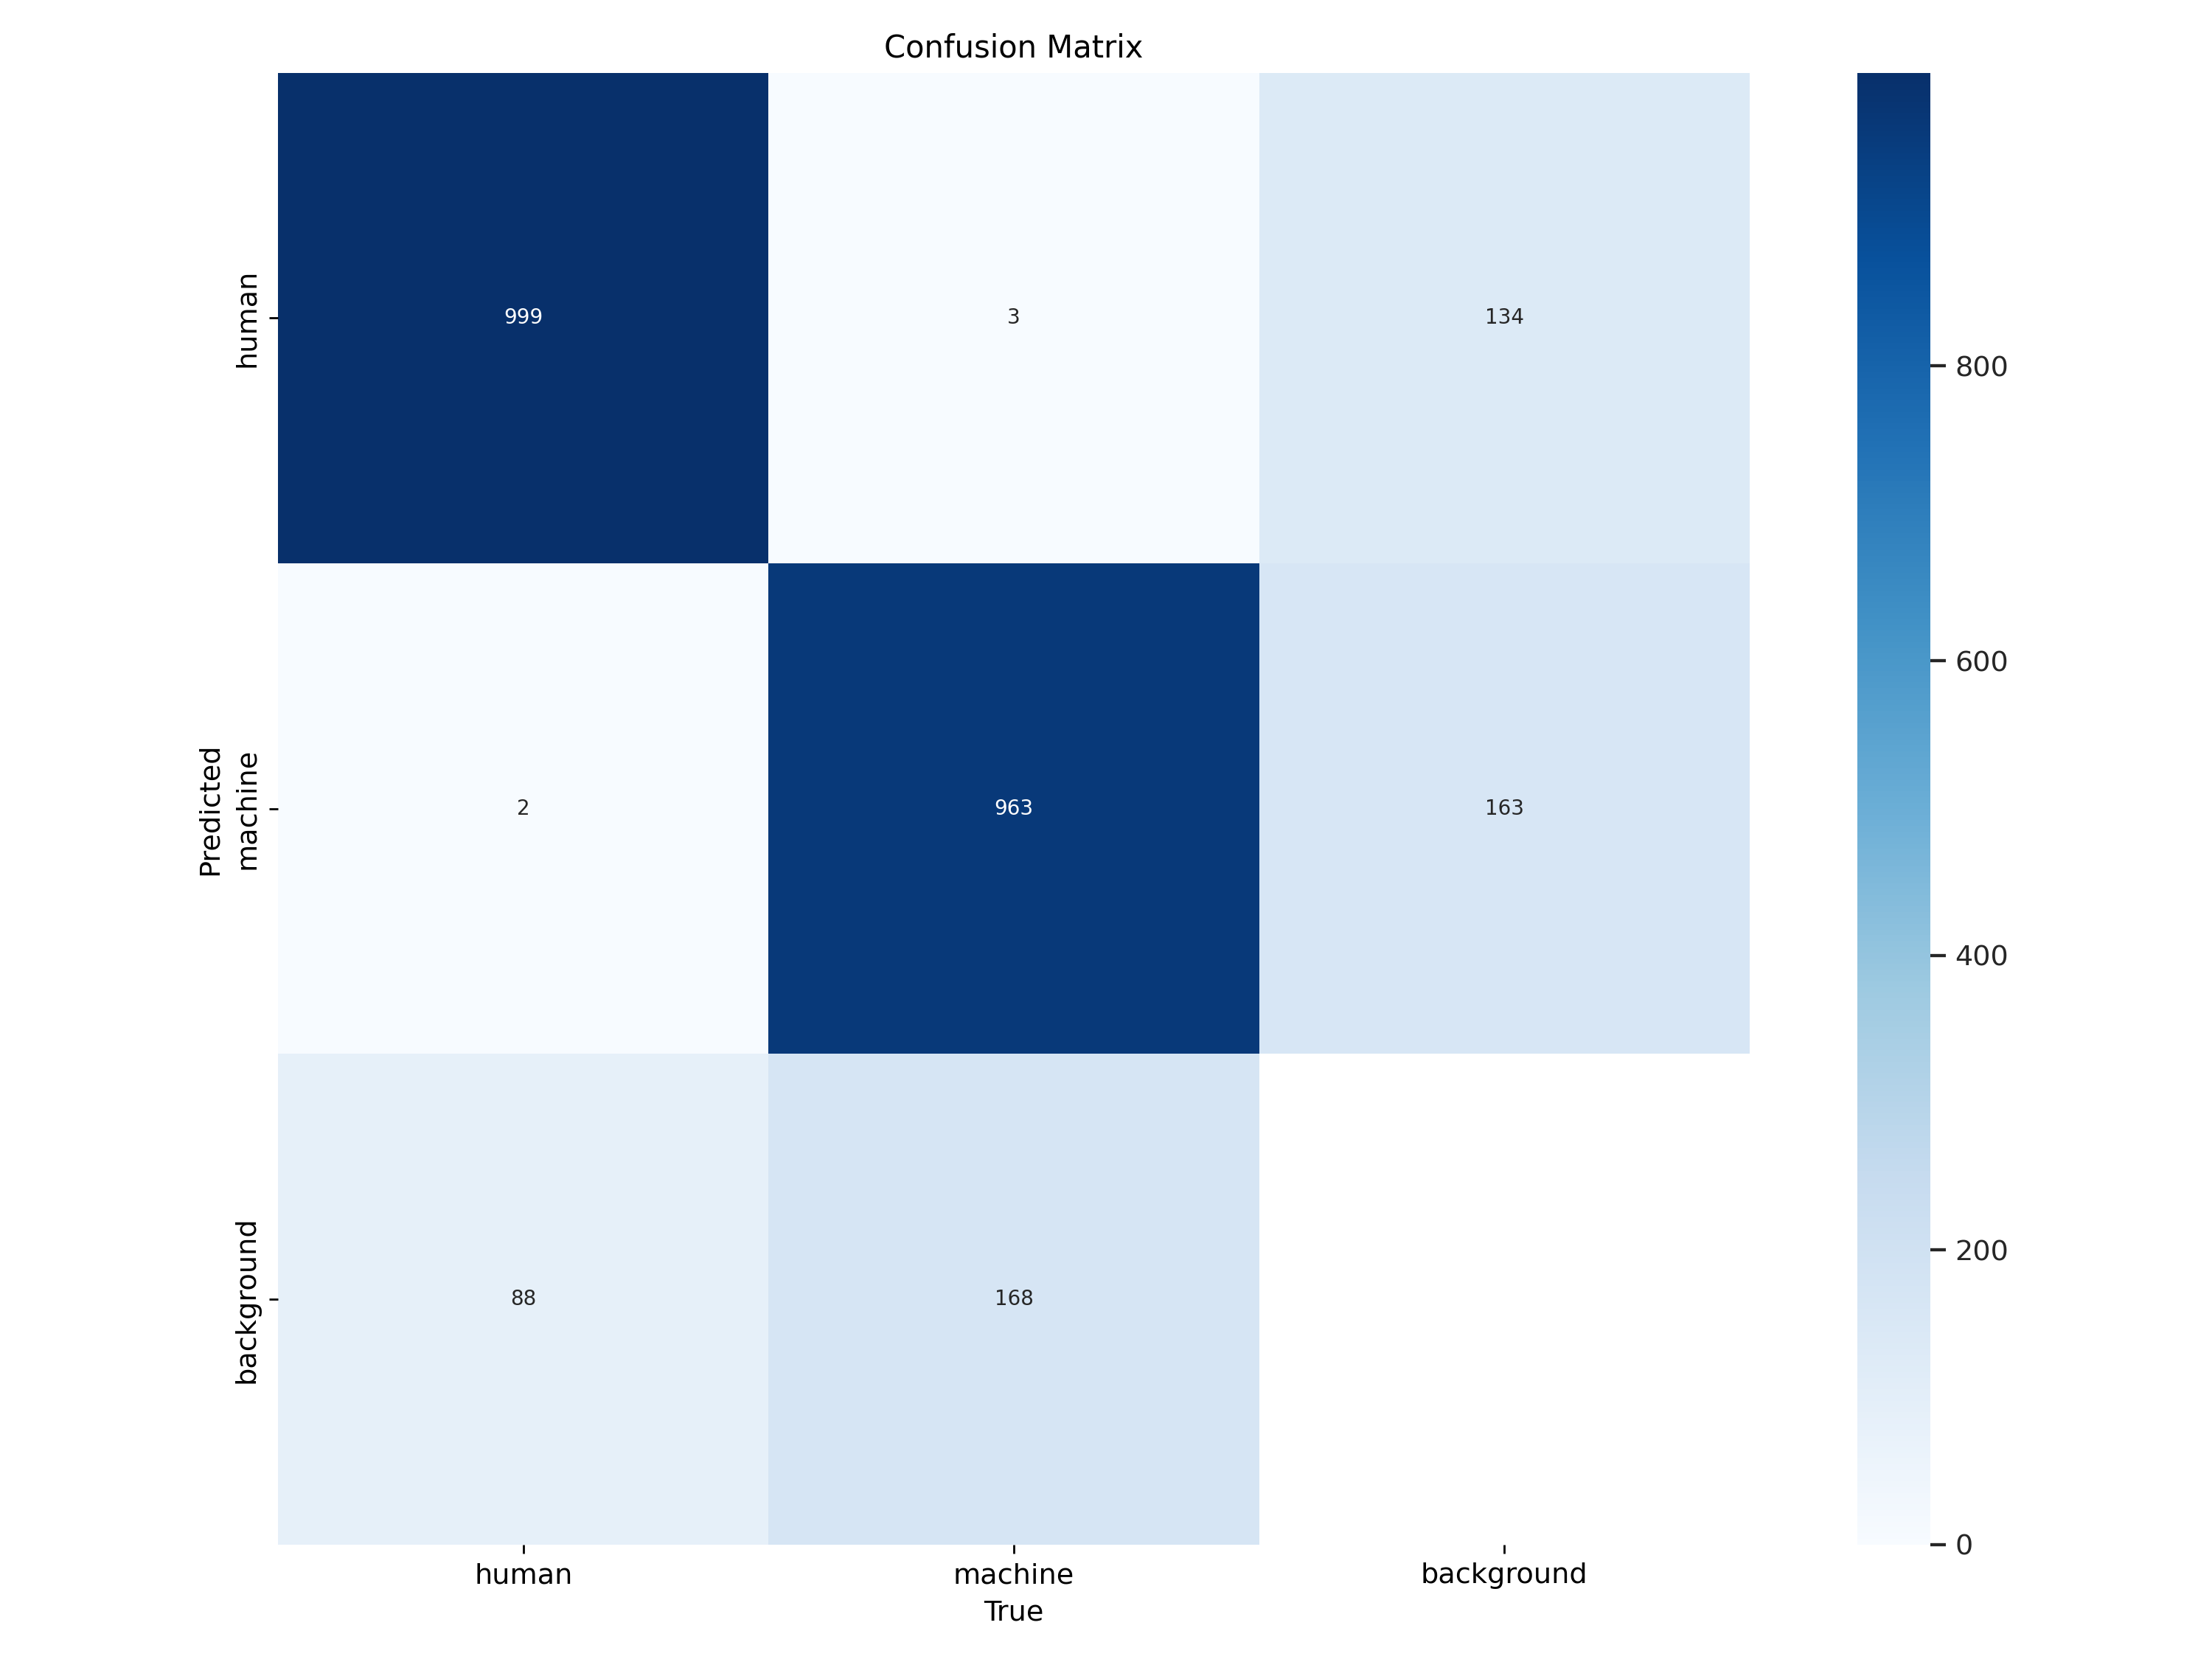

In [ ]:
from IPython.display import Image

# Define the path to the confusion matrix image file
confusion_matrix_path = '/content/smart-poultry-farm-litter-raking-3/runs/detect/train2/confusion_matrix.png'

# Display the confusion matrix image
Image(filename=confusion_matrix_path, width=640)

# Visualize the normalized confusion matrix

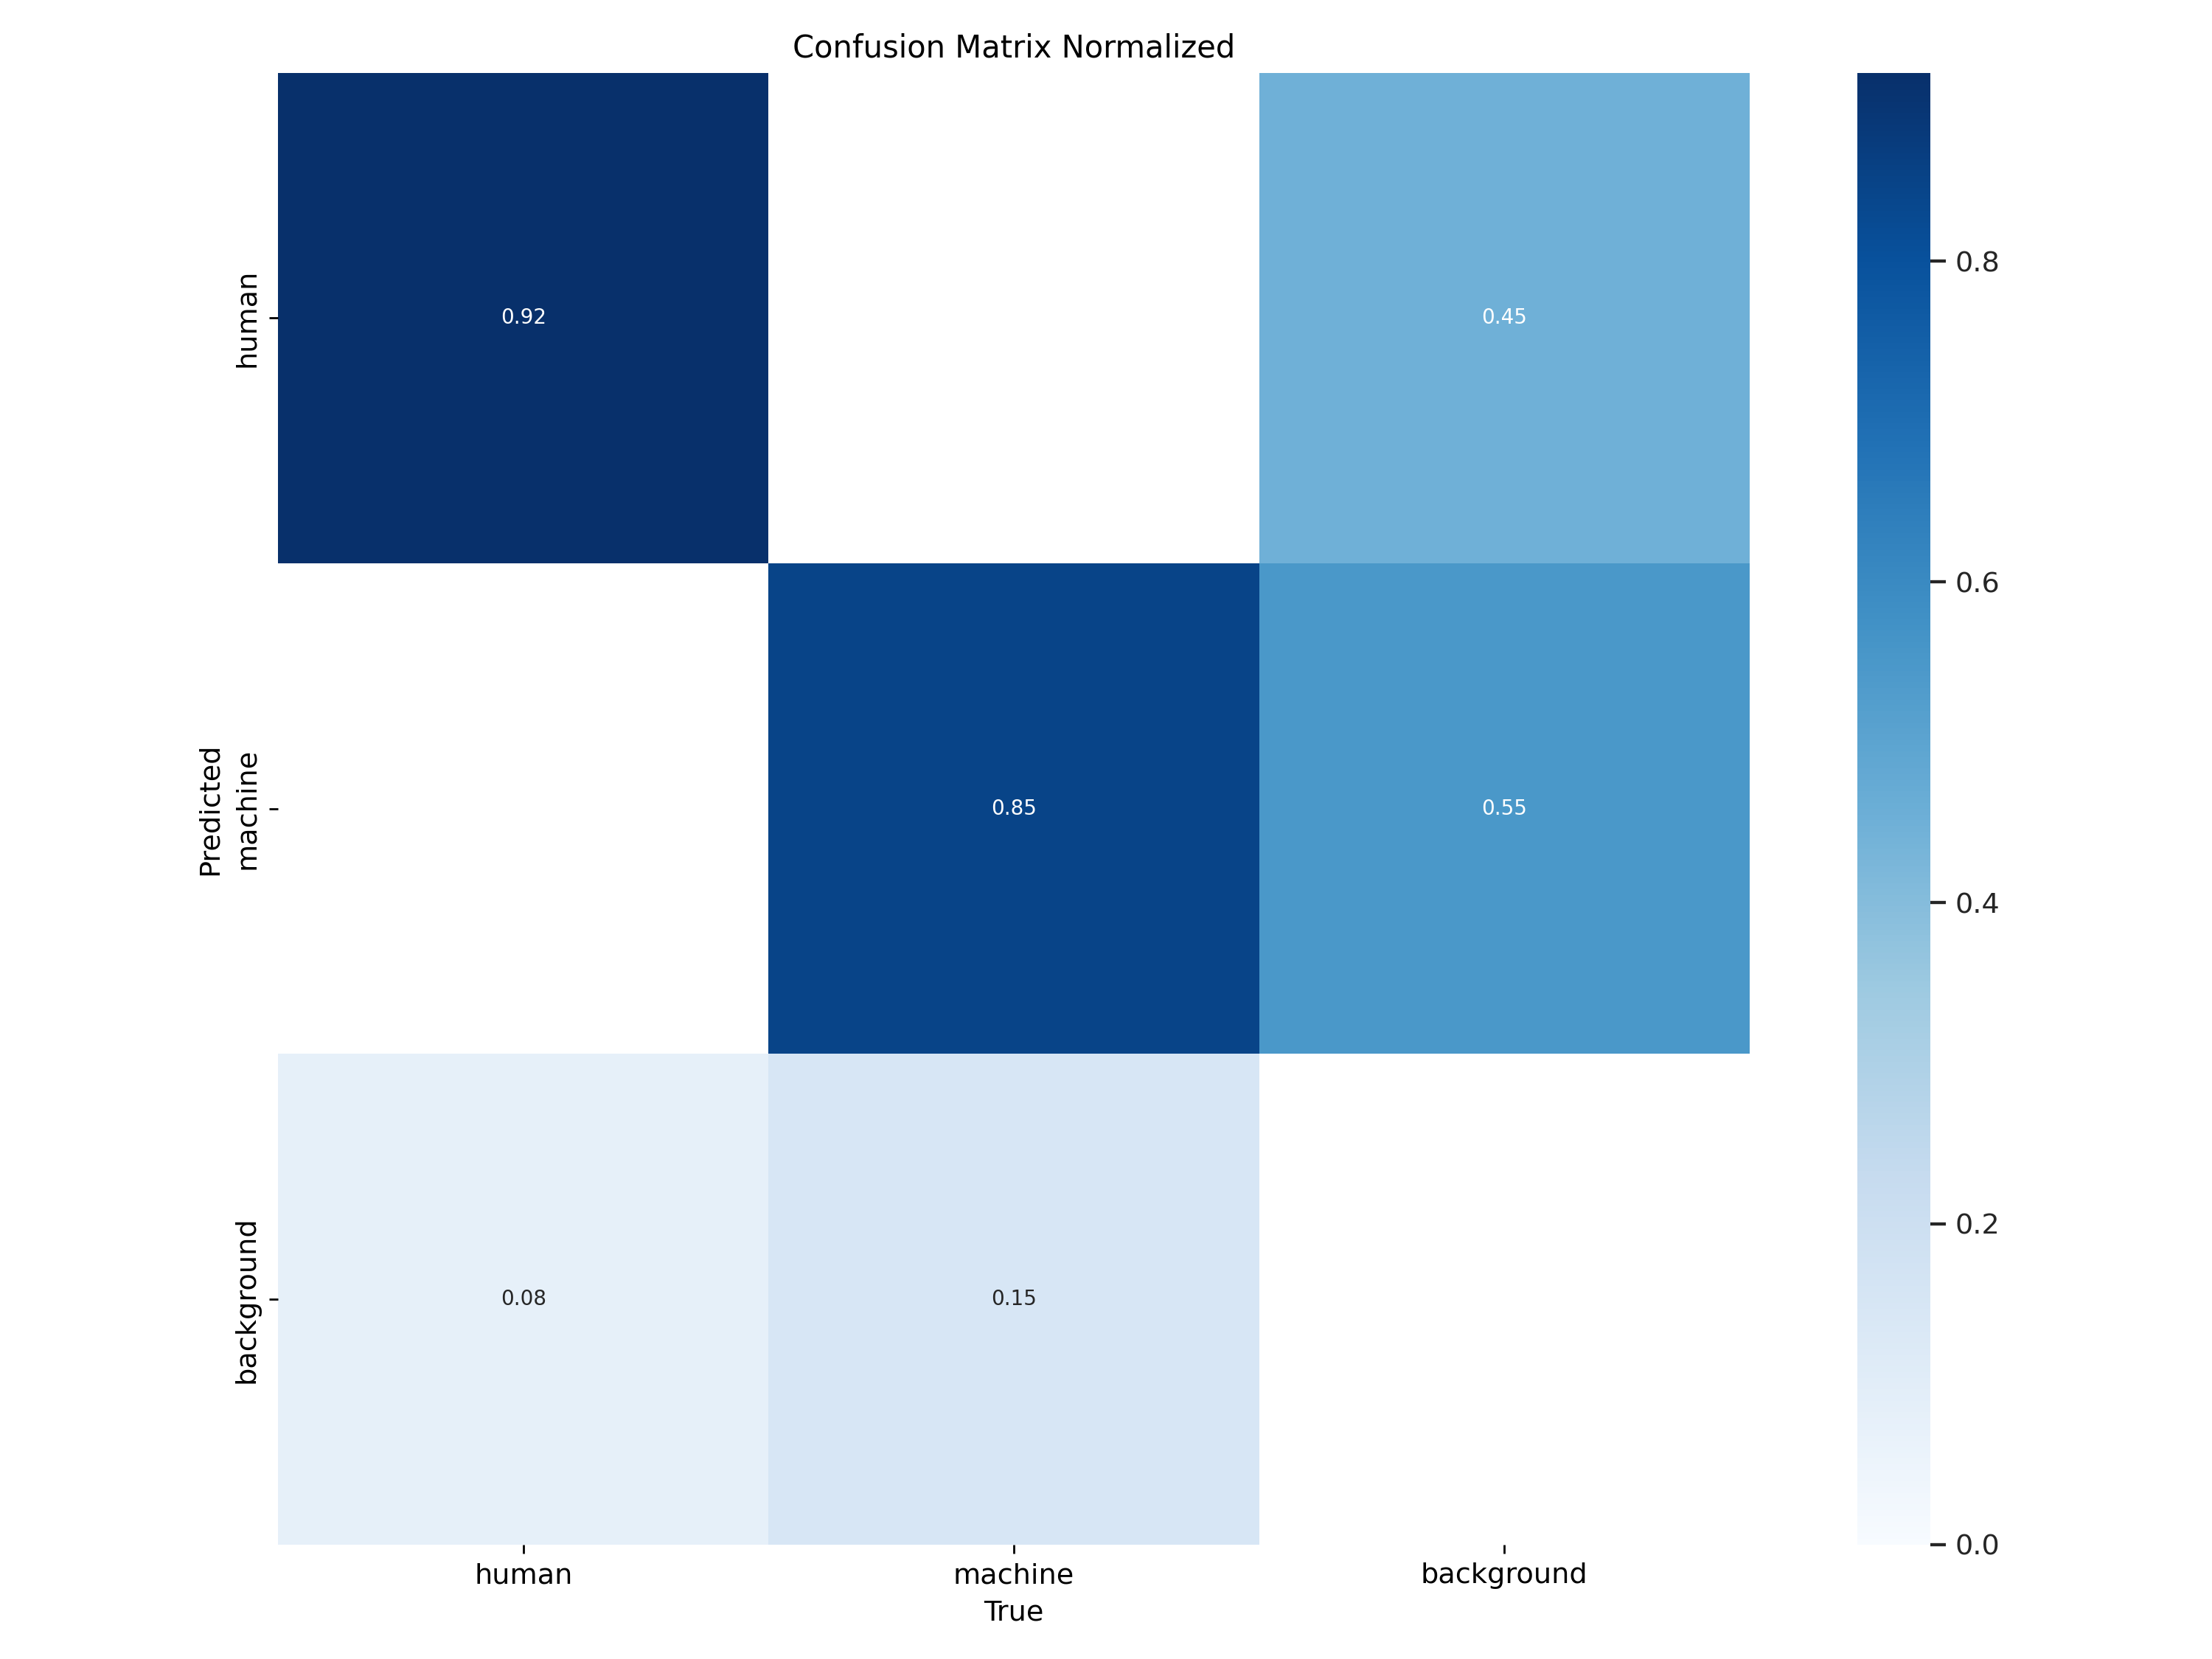

In [ ]:
from IPython.display import Image

# Define the path to the confusion matrix image file
confusion_matrix_path = '/content/smart-poultry-farm-litter-raking-3/runs/detect/train2/confusion_matrix_normalized.png'

# Display the confusion matrix image
Image(filename=confusion_matrix_path, width=640)

# Visualize labels


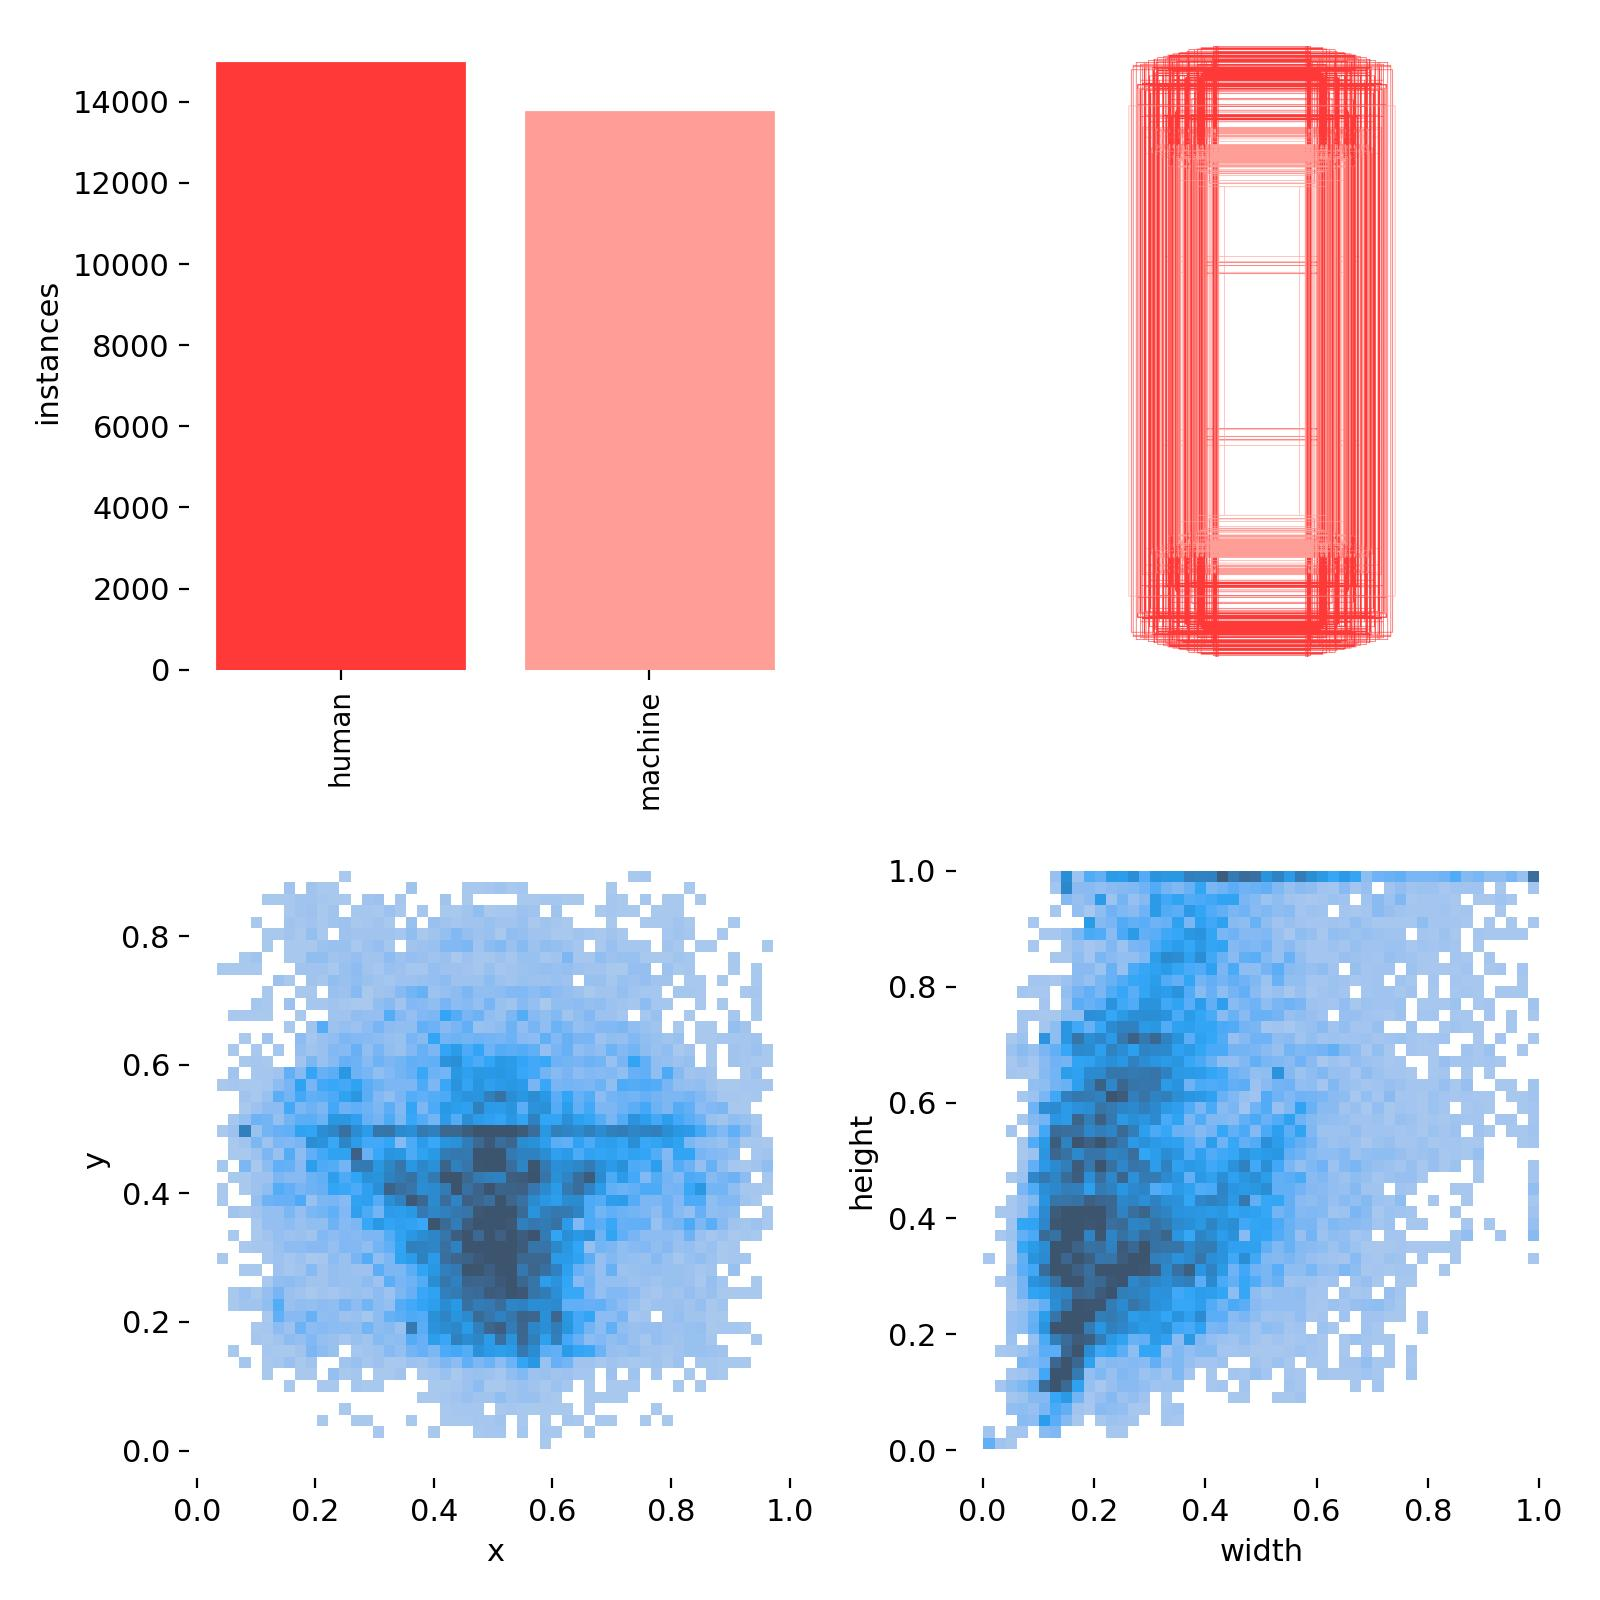

In [ ]:
# Define the path to the labels image file
labels_path = '/content/drive/MyDrive/Litte-Racking-Project-files Drive/train2/labels.jpg'

# Display the labels image
Image(filename=labels_path, width=640)


# Visualize labels_correlogram

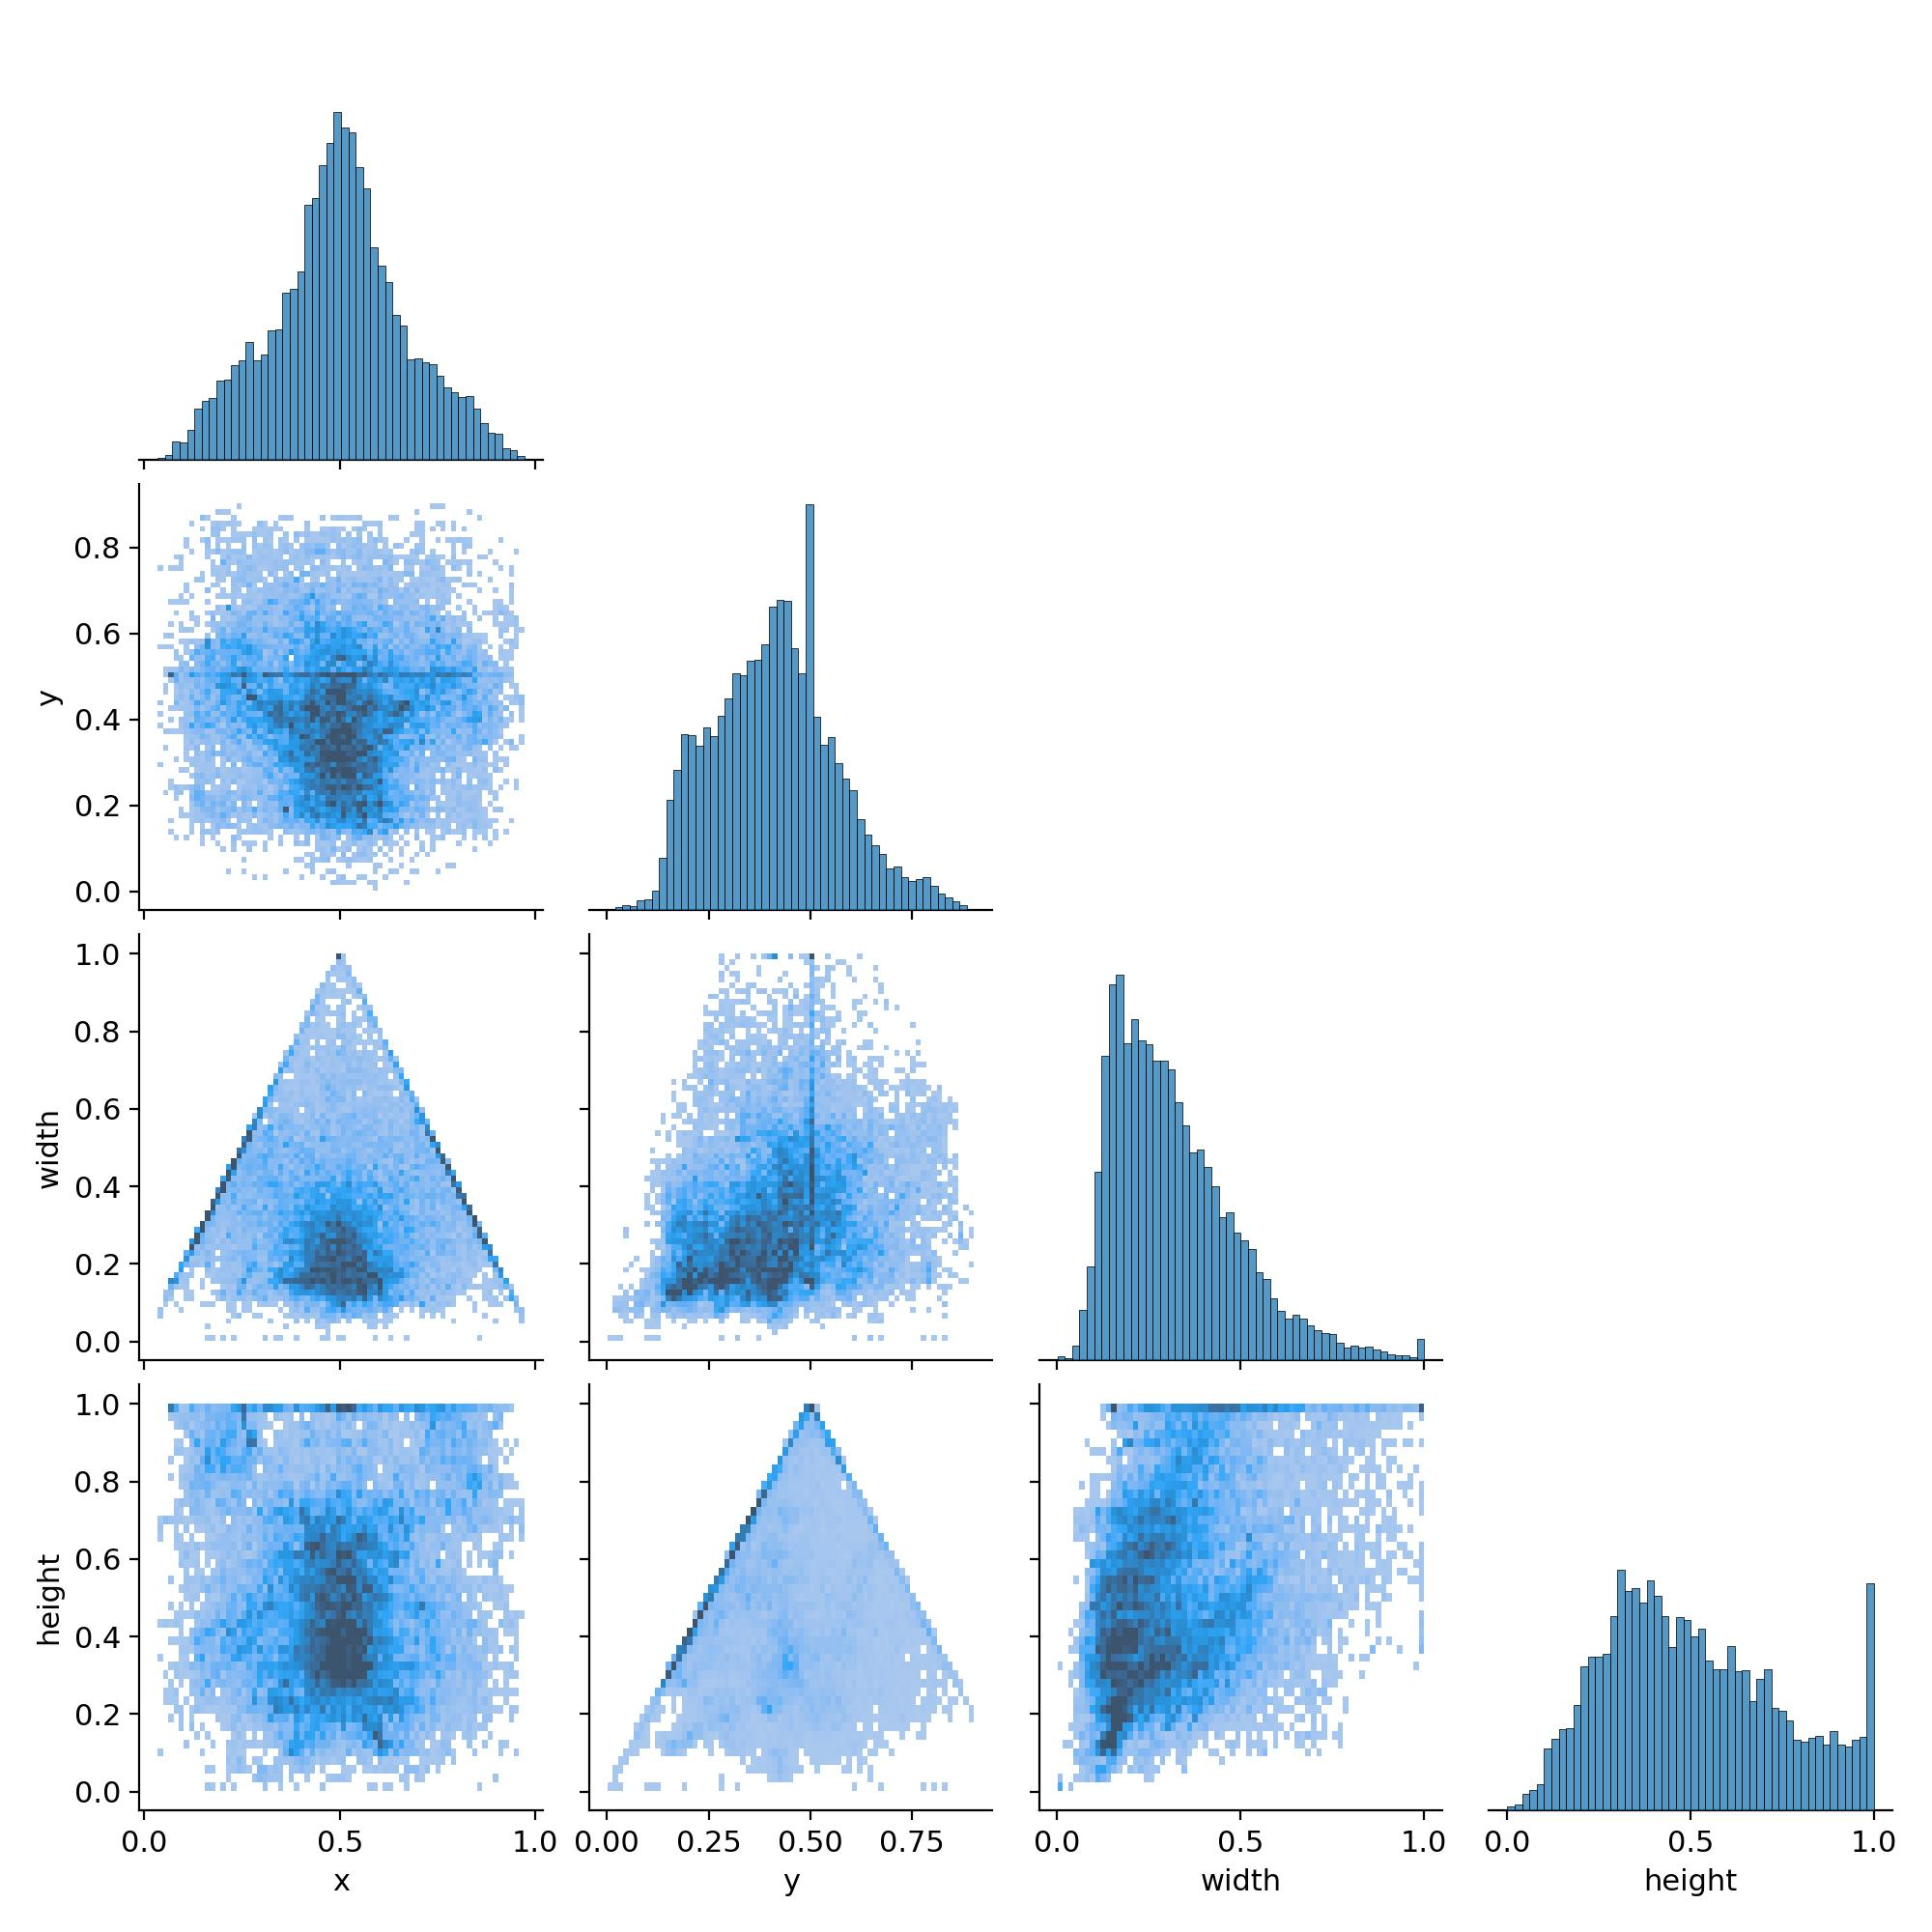

In [ ]:
# Define the path to the labels_correlogram image file
labels_correlogram_path = '/content/drive/MyDrive/Litte-Racking-Project-files Drive/train2/labels_correlogram.jpg'

# Display the labels_correlogram image
Image(filename=labels_correlogram_path, width=640)


# Visualize results

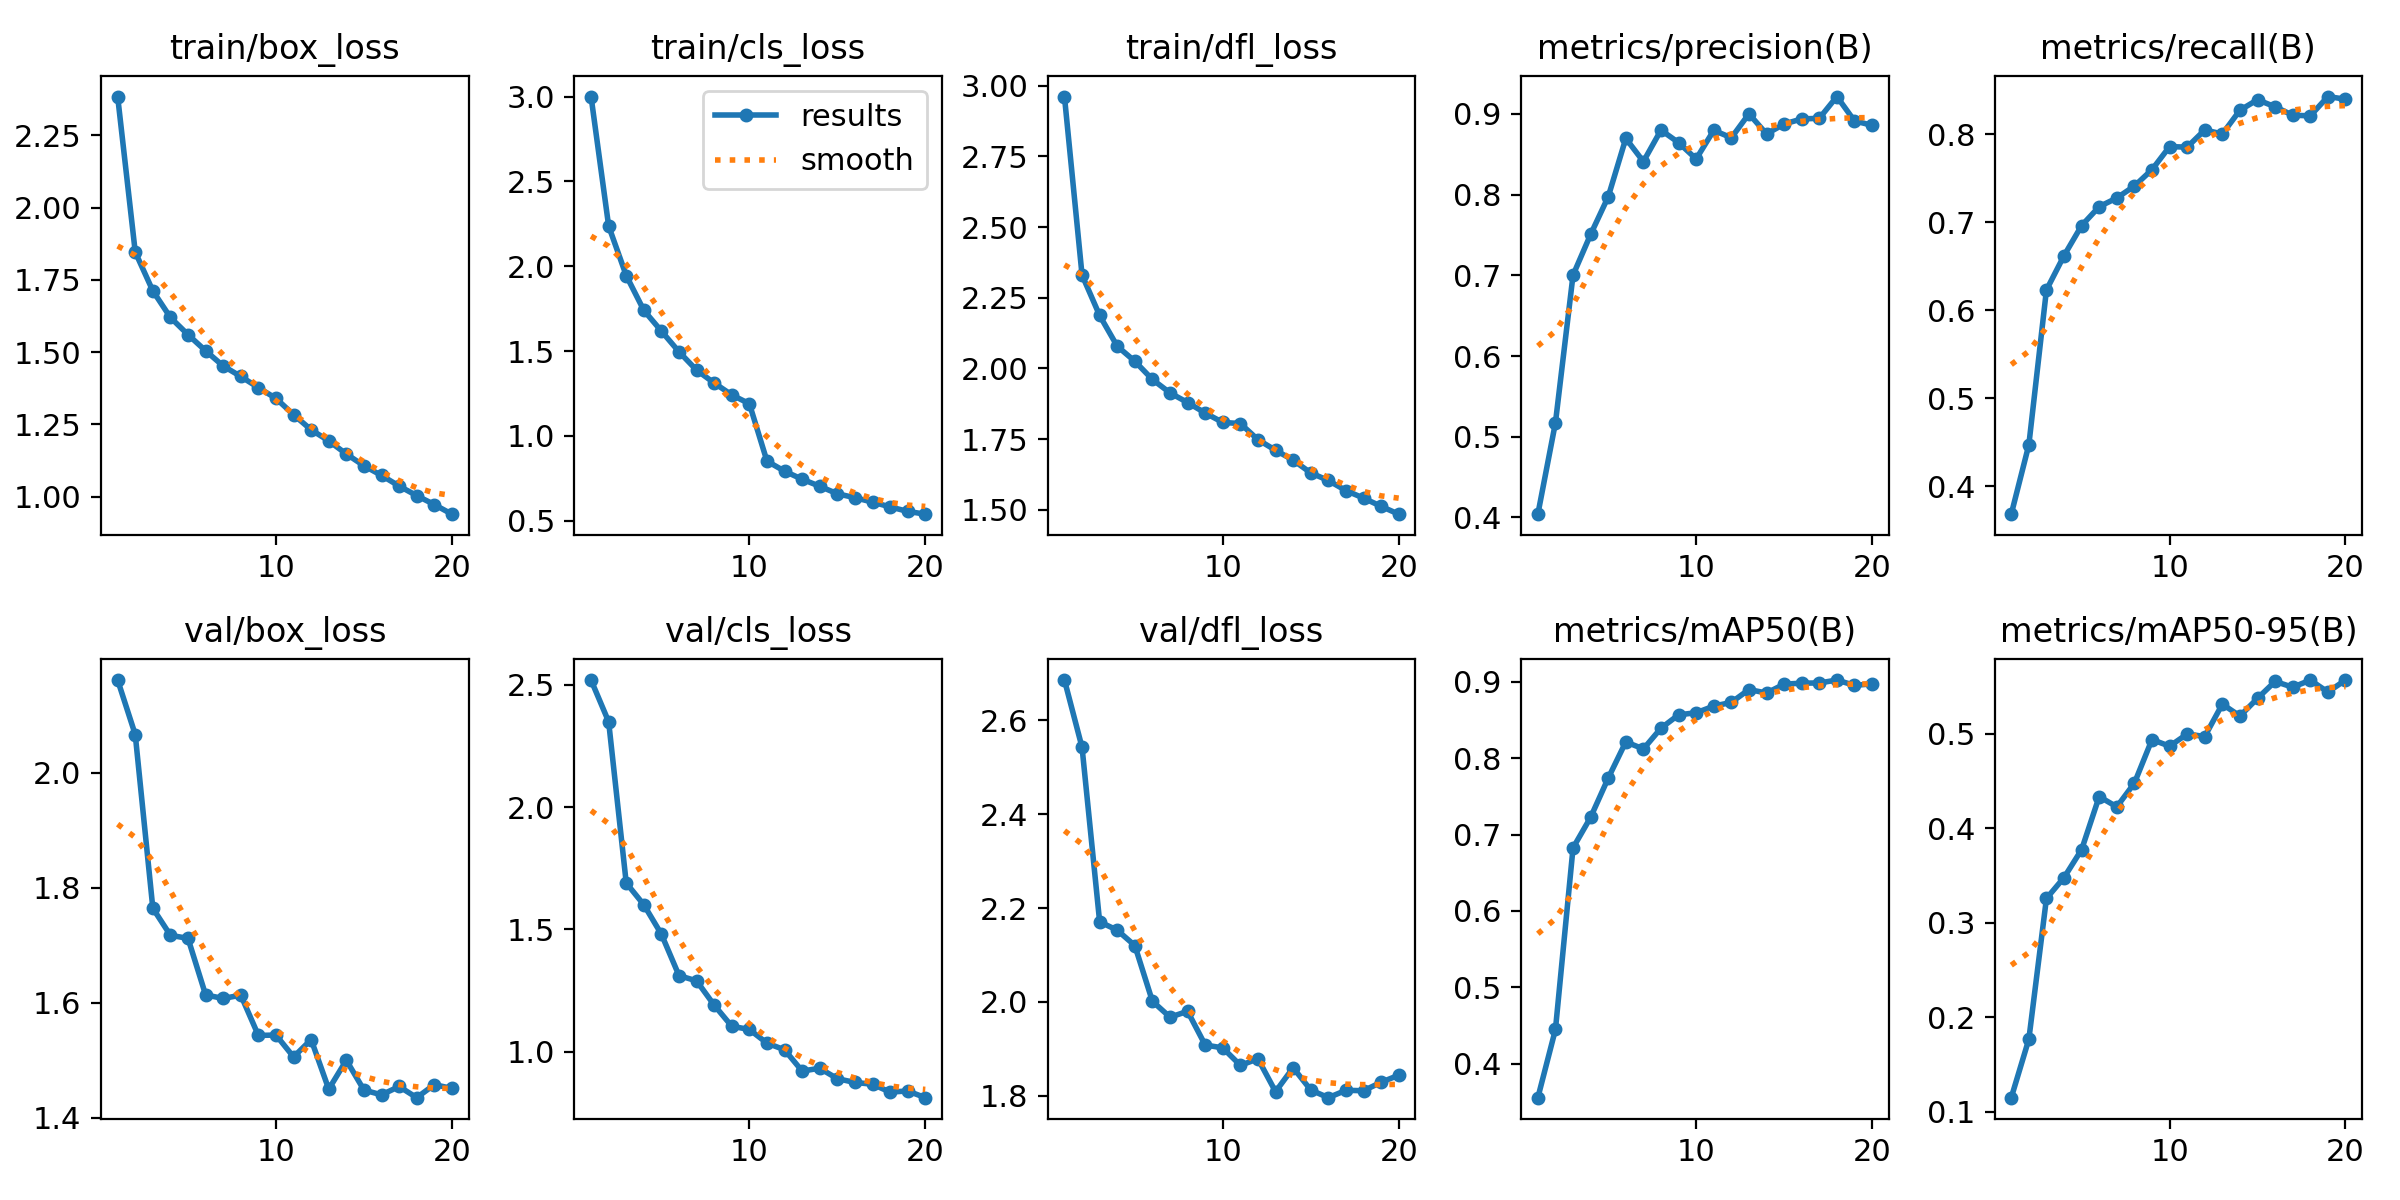

In [ ]:
# Define the path to the Results image file
results = '/content/drive/MyDrive/Litte-Racking-Project-files Drive/train2/results.png'

# Display the results image
Image(filename=results)


# Perform testing and prediction

In [ ]:
# Test
!yolo detect predict  model=/content/best.pt conf=0.25 source=/content/smart-poultry-farm-litter-raking-3/test/images show=True save=True save_txt=True save_conf=True show_labels=True show_conf=True show_boxes=True

WARNING ⚠️ Environment does not support cv2.imshow() or PIL Image.show()

Ultralytics YOLOv8.1.40 🚀 Python-3.10.12 torch-2.2.1+cu121 CPU (Intel Xeon 2.20GHz)
YOLOv8m summary (fused): 218 layers, 25840918 parameters, 0 gradients, 78.7 GFLOPs

image 1/603 /content/smart-poultry-farm-litter-raking-3/test/images/-trashed-1713364327-vf_how-to-do-Litter-raking-in-poultry-farm-_chicken-_farming-_poultrytreatment-_poultrydiseases-480P-_11000_jpeg_jpg.rf.e3eceffa14a1caa23fda46f08a9d9ca7.jpg: 640x640 1 human, 1 machine, 1557.5ms
image 2/603 /content/smart-poultry-farm-litter-raking-3/test/images/-trashed-1713364335-vf_how-to-do-Litter-raking-in-poultry-farm-_chicken-_farming-_poultrytreatment-_poultrydiseases-480P-_6000_jpeg_jpg.rf.d2f0e790565f6d06966e1621e271d447.jpg: 640x640 1 human, 1 machine, 1326.0ms
image 3/603 /content/smart-poultry-farm-litter-raking-3/test/images/-trashed-1713364337-vf_how-to-do-Litter-raking-in-poultry-farm-_chicken-_farming-_poultrytreatment-_poultrydiseases-480P-_500

# Visualize test images along with predictions

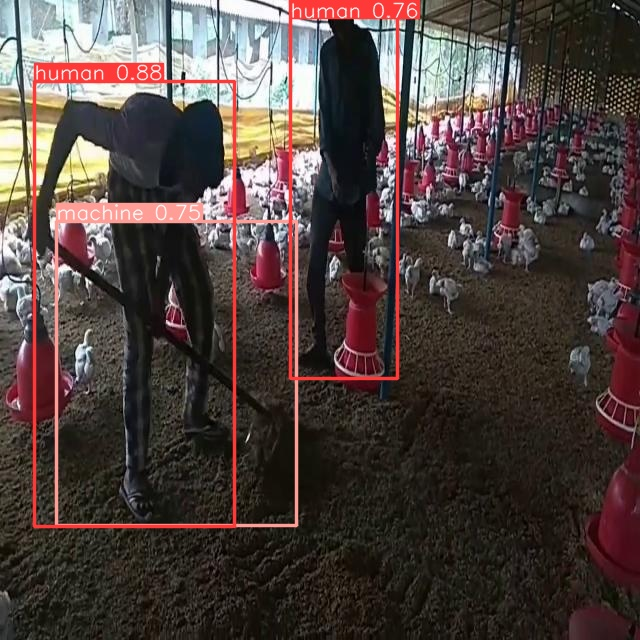

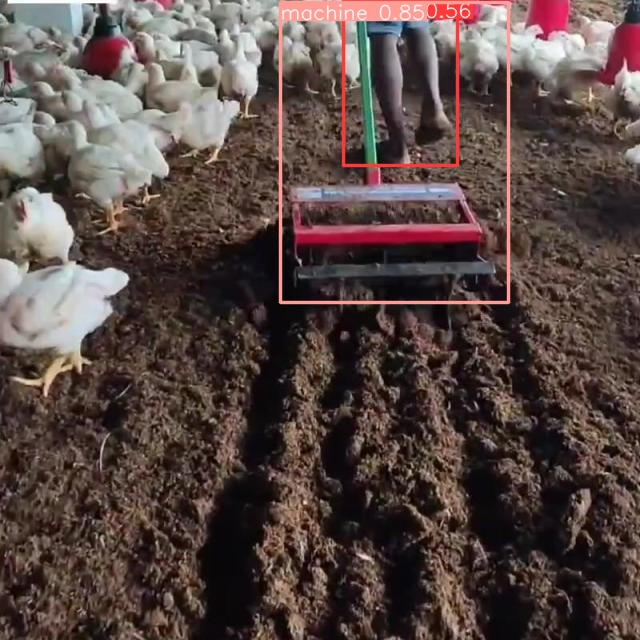

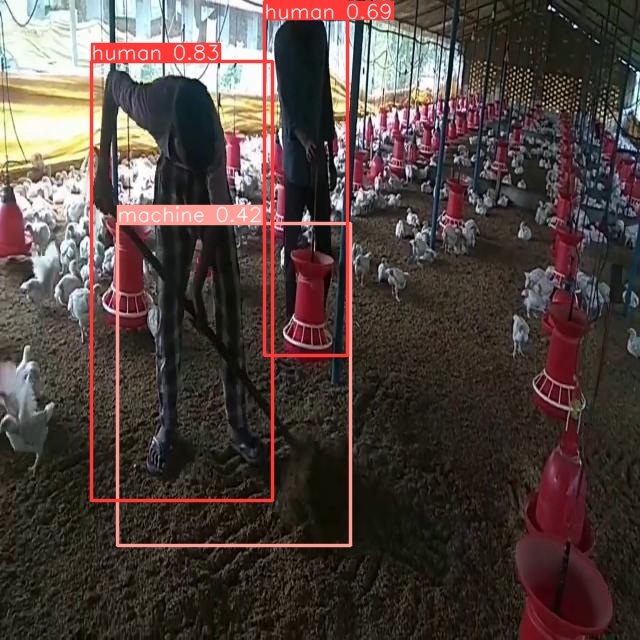

In [ ]:
from PIL import Image
from IPython.display import display
import os

# Define the directory containing the images
images_dir = '/content/smart-poultry-farm-litter-raking-3/runs/detect/predict2'
# Get a list of image filenames
image_files = os.listdir(images_dir)

# Display a few sample images
num_samples = 3  # Number of samples to display
for i in range(num_samples):
    try:
        # Get the image filename
        image_filename = image_files[i]

        # Define the path to the image file
        image_path = os.path.join(images_dir, image_filename)

        # Load the image
        image = Image.open(image_path)

        # Display the image
        display(image)
    except IndexError:
        print(f"No more images to display after {i} samples.")
        break
    except FileNotFoundError:
        print(f"File not found: {image_filename}, skipping to the next file.")
        continue


# Test with an image that the model has not seen before

In [ ]:
# Test with an image that the model has not seen before
!yolo detect predict model=/content/drive/MyDrive/best.pt source=/content/sddefault.jpg conf=0.25 save_txt=True show_labels=True show_conf=True show_boxes=True visualize=True

Ultralytics YOLOv8.1.40 🚀 Python-3.10.12 torch-2.2.1+cu121 CPU (Intel Xeon 2.20GHz)
YOLOv8m summary (fused): 218 layers, 25840918 parameters, 0 gradients, 78.7 GFLOPs

Saving runs/detect/predict/sddefault/stage0_Conv_features.png... (32/48)
Saving runs/detect/predict/sddefault/stage1_Conv_features.png... (32/96)
Saving runs/detect/predict/sddefault/stage2_C2f_features.png... (32/96)
Saving runs/detect/predict/sddefault/stage3_Conv_features.png... (32/192)
Saving runs/detect/predict/sddefault/stage4_C2f_features.png... (32/192)
Saving runs/detect/predict/sddefault/stage5_Conv_features.png... (32/384)
Saving runs/detect/predict/sddefault/stage6_C2f_features.png... (32/384)
Saving runs/detect/predict/sddefault/stage7_Conv_features.png... (32/576)
Saving runs/detect/predict/sddefault/stage8_C2f_features.png... (32/576)
Saving runs/detect/predict/sddefault/stage9_SPPF_features.png... (32/576)
Saving runs/detect/predict/sddefault/stage10_Upsample_features.png... (32/576)
Saving runs/detect/p

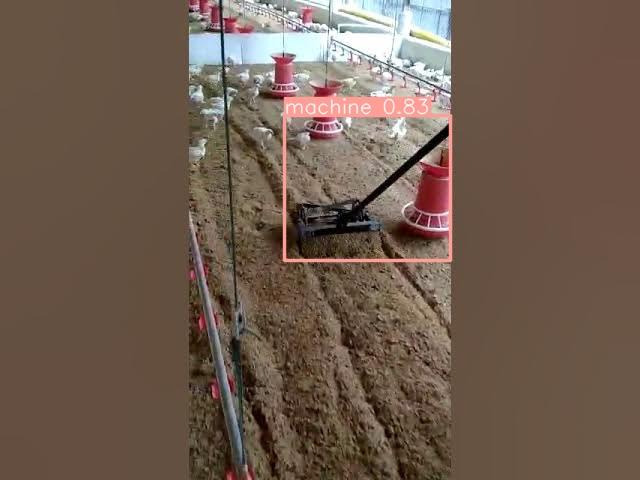

In [ ]:
from PIL import Image
from IPython.display import display

image_path = '/content/smart-poultry-farm-litter-raking-3/runs/detect/predict/sddefault.jpg'
image = Image.open(image_path)

# Display the image in the notebook
display(image)


In [ ]:
import os
HOME = os.getcwd()
print(HOME)

/content/smart-poultry-farm-litter-raking-3


In [ ]:
# Install gdown if not already installed
!pip install gdown

import gdown

# Define the Google Drive file URL
file_url = 'https://drive.google.com/uc?id=1nYUU2AdEmYKxPXXlFJP34KGjfgFA1UjP'

# Define the output file path where you want to save the downloaded file
output_path = '/content/drive/MyDrive/test.mp4'

# Download the file
gdown.download(file_url, output_path, quiet=False)


Downloading...
From: https://drive.google.com/uc?id=1nYUU2AdEmYKxPXXlFJP34KGjfgFA1UjP
To: /content/drive/MyDrive/test.mp4
100%|██████████| 1.02M/1.02M [00:00<00:00, 10.8MB/s]


'/content/drive/MyDrive/test.mp4'

In [ ]:
%cd {HOME}
!git clone https://github.com/ifzhang/ByteTrack.git
%cd {HOME}/ByteTrack

# workaround related to https://github.com/roboflow/notebooks/issues/80
!sed -i 's/onnx==1.8.1/onnx==1.9.0/g' requirements.txt

!pip3 install -q -r requirements.txt
!python3 setup.py -q develop
!pip install -q cython_bbox
!pip install -q onemetric
# workaround related to https://github.com/roboflow/notebooks/issues/112 and https://github.com/roboflow/notebooks/issues/106
!pip install -q loguru lap thop

from IPython import display
display.clear_output()


import sys
sys.path.append(f"{HOME}/ByteTrack")


import yolox
print("yolox.__version__:", yolox.__version__)

yolox.__version__: 0.1.0


In [ ]:
from yolox.tracker.byte_tracker import BYTETracker, STrack
from onemetric.cv.utils.iou import box_iou_batch
from dataclasses import dataclass


@dataclass(frozen=True)
class BYTETrackerArgs:
    track_thresh: float = 0.25
    track_buffer: int = 30
    match_thresh: float = 0.8
    aspect_ratio_thresh: float = 3.0
    min_box_area: float = 1.0
    mot20: bool = False

## Install Roboflow Supervision

In [ ]:
!pip install supervision==0.1.0


from IPython import display
display.clear_output()


import supervision
print("supervision.__version__:", supervision.__version__)

supervision.__version__: 0.1.0


In [ ]:
from supervision.draw.color import ColorPalette
from supervision.geometry.dataclasses import Point
from supervision.video.dataclasses import VideoInfo
from supervision.video.source import get_video_frames_generator
from supervision.video.sink import VideoSink
from supervision.notebook.utils import show_frame_in_notebook
from supervision.tools.detections import Detections, BoxAnnotator
from supervision.tools.line_counter import LineCounter, LineCounterAnnotator

## Tracking utils

Unfortunately, we have to manually match the bounding boxes coming from our model with those created by the tracker.

In [ ]:
from typing import List

import numpy as np


# converts Detections into format that can be consumed by match_detections_with_tracks function
def detections2boxes(detections: Detections) -> np.ndarray:
    return np.hstack((
        detections.xyxy,
        detections.confidence[:, np.newaxis]
    ))


# converts List[STrack] into format that can be consumed by match_detections_with_tracks function
def tracks2boxes(tracks: List[STrack]) -> np.ndarray:
    return np.array([
        track.tlbr
        for track
        in tracks
    ], dtype=float)


# matches our bounding boxes with predictions
def match_detections_with_tracks(
    detections: Detections,
    tracks: List[STrack]
) -> Detections:
    if not np.any(detections.xyxy) or len(tracks) == 0:
        return np.empty((0,))

    tracks_boxes = tracks2boxes(tracks=tracks)
    iou = box_iou_batch(tracks_boxes, detections.xyxy)
    track2detection = np.argmax(iou, axis=1)

    tracker_ids = [None] * len(detections)

    for tracker_index, detection_index in enumerate(track2detection):
        if iou[tracker_index, detection_index] != 0:
            tracker_ids[detection_index] = tracks[tracker_index].track_id

    return tracker_ids

## Load pre-trained YOLOv8 model

In [ ]:
# settings
MODEL = "/content/drive/MyDrive/best.pt"

In [ ]:
from ultralytics import YOLO

model = YOLO(MODEL)
model.fuse()

YOLOv8m summary (fused): 218 layers, 25840918 parameters, 0 gradients, 78.7 GFLOPs


#Files will be in ByteTrack -> Run -> Detect ->file

In [ ]:
# Test with an image that the model has not seen before
!yolo detect predict model=/content/drive/MyDrive/best.pt source={output_path}



Ultralytics YOLOv8.1.40 🚀 Python-3.10.12 torch-2.2.1+cu121 CPU (Intel Xeon 2.20GHz)
YOLOv8m summary (fused): 218 layers, 25840918 parameters, 0 gradients, 78.7 GFLOPs

video 1/1 (frame 1/2474) /content/drive/MyDrive/Your_File.mp4: 640x384 1 human, 1 machine, 980.9ms
video 1/1 (frame 2/2474) /content/drive/MyDrive/Your_File.mp4: 640x384 1 human, 1 machine, 878.7ms
video 1/1 (frame 3/2474) /content/drive/MyDrive/Your_File.mp4: 640x384 1 human, 1 machine, 823.4ms
video 1/1 (frame 4/2474) /content/drive/MyDrive/Your_File.mp4: 640x384 1 human, 1 machine, 1296.8ms
video 1/1 (frame 5/2474) /content/drive/MyDrive/Your_File.mp4: 640x384 1 human, 1 machine, 1326.7ms
video 1/1 (frame 6/2474) /content/drive/MyDrive/Your_File.mp4: 640x384 1 human, 1 machine, 1392.1ms
video 1/1 (frame 7/2474) /content/drive/MyDrive/Your_File.mp4: 640x384 1 human, 1 machine, 1126.2ms
video 1/1 (frame 8/2474) /content/drive/MyDrive/Your_File.mp4: 640x384 1 human, 1 machine, 880.8ms
video 1/1 (frame 9/2474) /content/dr

In [ ]:
import os
cd = os.getcwd()
print(cd)

/content/smart-poultry-farm-litter-raking-3/ByteTrack


## Predict and annotate single frame

In [ ]:
# dict maping class_id to class_name
CLASS_NAMES_DICT = model.model.names
# class_ids of interest - human, machine
CLASS_ID = [0,1]


0: 352x640 1 human, 1 machine, 875.1ms
Speed: 2.3ms preprocess, 875.1ms inference, 7.1ms postprocess per image at shape (1, 3, 352, 640)


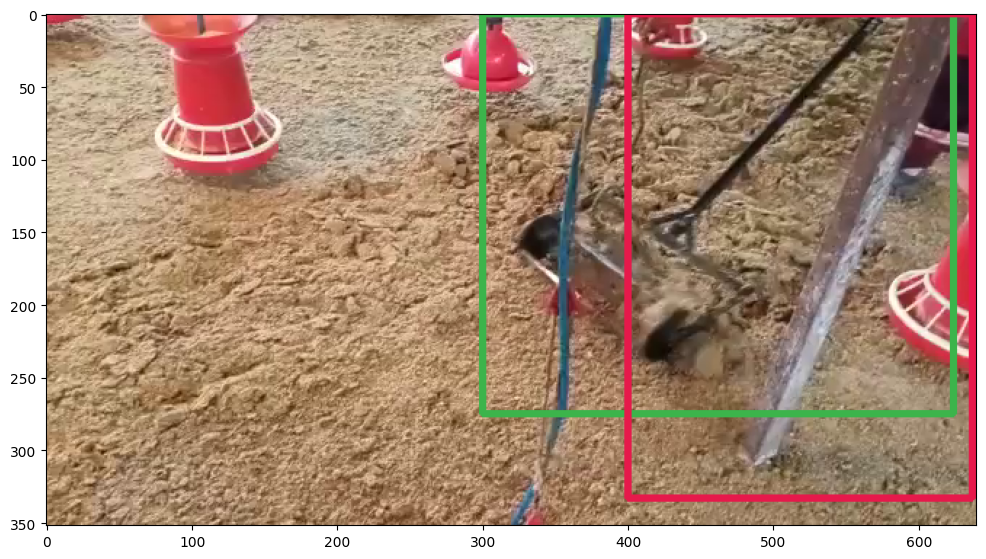

In [ ]:
# create frame generator
generator = get_video_frames_generator(output_path)
# create instance of BoxAnnotator
box_annotator = BoxAnnotator(color=ColorPalette(), thickness=4, text_thickness=4, text_scale=2)
# acquire first video frame
iterator = iter(generator)
frame = next(iterator)
# model prediction on single frame and conversion to supervision Detections
results = model(frame)
detections = Detections(
    xyxy=results[0].boxes.xyxy.cpu().numpy(),
    confidence=results[0].boxes.conf.cpu().numpy(),
    class_id=results[0].boxes.cls.cpu().numpy().astype(int)
)
# format custom labels
labels = [
    f"{CLASS_NAMES_DICT[class_id]} {confidence:0.2f}"
    for _, confidence, class_id, tracker_id
    in detections
]
# annotate and display frame
frame = box_annotator.annotate(frame=frame, detections=detections, labels=labels)

%matplotlib inline
show_frame_in_notebook(frame, (12, 12))